## Coverage calculations

All files on farm in `/home/ctbrown/scratch3/2025-workflow-core99/`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# outputs from running `do_mapping`:
BASE_OUTPUTS=BASE+'/outputs.mapping/bams.cds.rand'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy
import math
import sourmash
import collections

import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

In [3]:
NAMES = [ x.strip() for x in open(BASE+'/inputs.cds/names-plus.list') ]
print(f'loaded {len(NAMES)} species names')

SPECIAL = [ x.strip() for x in open(BASE+'/inputs.cds/names.list') ]
print(f'loaded {len(NAMES)} special species names')

NAMES.sort()
NAMES

loaded 27 species names
loaded 27 special species names


['s__Bariatricus sp004560705',
 's__Bifidobacterium thermacidophilum',
 's__Blautia_A sp945872375',
 's__CAG-269 sp014846485',
 's__CAG-465 sp000433755',
 's__CAG-873 sp016302215',
 's__Colivicinus sp002299675',
 's__Cryptobacteroides sp000432655',
 's__Cryptobacteroides sp000434935',
 's__Cryptobacteroides sp034089285',
 's__Cryptobacteroides sp900546925',
 's__Fimisoma sp002320005',
 's__Floccifex porci',
 's__JAFBIX01 sp021531895',
 's__Lactobacillus amylovorus',
 's__Mogibacterium_A kristiansenii',
 's__Ornithospirochaeta sp022785155',
 's__Phascolarctobacterium_A succinatutens_B',
 's__Prevotella sp000434975',
 's__Prevotella sp002251295',
 's__Ruminococcoides sp902766885',
 's__Ruminococcus_C sp000433635',
 's__SIG351 sp945918795',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595',
 's__UMGS1225 sp034086705',
 's__Ventricola sp017937505']

## Load manysearch of all species against 3,216 metagenomes

& rename columns etc etc.

In [4]:
manysearch_df = pl.read_csv('../outputs.cds/cds3/manysearch.cds3.3216.csv').with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    (pl.col("intersect_hashes") * pl.col("scaled") / pl.col("containment")).alias("sketch_size"),
)


In [5]:
manysearch_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64
"""s__Cryptobacteroides sp0004326…","""33ab318886b78679c8de5e106ac6b9…","""SRR11125436""",0.045958,191,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000536,0.045958,1.356021,1.0,0.744229,0.86358,0.698971,0.781276,0.86358,259,950458,"""s__Cryptobacteroides sp0004326…","""SRR11125436""",4.156e6
"""s__Bariatricus sp004560705""","""a053514b987f8c11e2ed518938e366…","""SRR11125436""",0.127554,387,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.001089,0.127554,1.757106,1.0,1.189063,0.906597,0.722874,0.814735,0.906597,680,950458,"""s__Bariatricus sp004560705""","""SRR11125436""",3.034e6
"""s__Floccifex porci""","""d517f763cae95c3706b3311e9ef0ca…","""SRR11125436""",0.071151,165,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000465,0.071151,1.569697,1.0,1.192015,0.881743,0.694117,0.78793,0.881743,259,950458,"""s__Floccifex porci""","""SRR11125436""",2.319e6
"""s__Cryptobacteroides sp0340892…","""376b4bdd83505f2f45acbe381d3914…","""SRR11125436""",0.097169,254,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000715,0.097169,1.767717,1.0,1.165946,0.894926,0.708524,0.801725,0.894926,449,950458,"""s__Cryptobacteroides sp0340892…","""SRR11125436""",2.614e6
"""s__Prevotella sp000434975""","""4736bc318783e81245554ed9fa261a…","""SRR11125436""",0.001619,11,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000031,0.001619,1.090909,1.0,0.28748,0.73639,0.610139,0.673264,0.73639,12,950458,"""s__Prevotella sp000434975""","""SRR11125436""",6.794e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Colivicinus sp002299675""","""751a24e45a6cdebaf4daf12fd0f355…","""ERR8314784""",0.382275,1294,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",0.000483,0.382275,2.958269,2.0,2.231873,0.955241,0.695173,0.825207,0.955241,3828,11178711,"""s__Colivicinus sp002299675""","""ERR8314784""",3.385e6
"""s__CAG-269 sp014846485""","""078c4569f257f75356832c47c16808…","""ERR8314784""",0.002294,1,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",3.7320e-7,0.002294,1.0,1.0,0.0,0.748704,0.494203,0.621453,0.748704,1,11178711,"""s__CAG-269 sp014846485""","""ERR8314784""",436000.0
"""s__UMGS1225 sp034086705""","""32711230ebb0936ab57ed263368289…","""ERR8314784""",0.051258,55,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",0.000021,0.051258,1.272727,1.0,0.645391,0.868081,0.598108,0.733094,0.868081,70,11178711,"""s__UMGS1225 sp034086705""","""ERR8314784""",1.073e6


## Convert columns from hashes into bp

In [6]:
manysearch_df = manysearch_df.with_columns(
    (pl.col('intersect_hashes')*1000).alias('intersect_bp'),
    (pl.col('n_weighted_found')*1000).alias('weighted_bp'),
)

## Build a basic coverage curve function

$$y = G (1 - e^{(-Cx)})$$

G is the genome size, C is the coverage exponent.

In [7]:
def coverage_curve(x, G, C):
    return G*(1 - np.exp(-C*x))

Text(0.5, 1.0, 'example coverage curve')

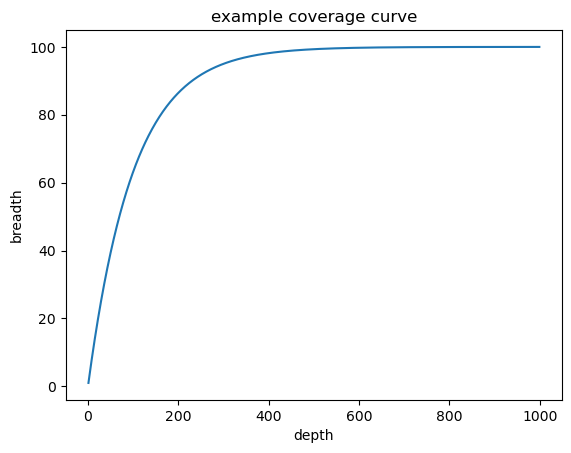

In [8]:
x = np.arange(1, 1000)
y = [ coverage_curve(xx, 100, .01) for xx in x ]
plt.plot(x, y)
plt.xlabel('depth')
plt.ylabel('breadth')
plt.title("example coverage curve")

## Build a fit function that takes weighted bp (x) and containment (y) and fits to a coverage curve

In [9]:
def do_fit(contain_df, *, fn=coverage_curve, p0=None):
    "Fit to given function, which takes two parameters, G and C. Return fit values & params."
    if p0 is None:
        p0 = (max(contain_df['weighted_bp']), .001)
    popt, pcov = scipy.optimize.curve_fit(fn, contain_df['weighted_bp'], contain_df['intersect_bp'], p0)
    G, C = popt

    y = np.asarray(contain_df['weighted_bp'])
    yfit = coverage_curve(y, G, C)

    # residual sum of squares
    ss_res = np.sum((y - yfit) ** 2)
    # total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    # r-squared
    r2 = 1 - (ss_res / ss_tot)

    return yfit, (G, C), r2

fitting for: s__Bariatricus sp004560705
fit params for s__Bariatricus sp004560705: G=1043049 C=6.186134960198795e-07; r2=-0.104


/group/datalabgrp/ctbrown/2025-grist-annie/.snakemake/conda/ab4c18c32e39b7f9ba11a10bc8c18bcf_/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: overflow encountered in exp
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/group/datalabgrp/ctbrown/2025-grist-annie/.snakemake/conda/ab4c18c32e39b7f9ba11a10bc8c18bcf_/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: overflow encountered in multiply
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


Text(0.5, 1.0, 's__Bariatricus sp004560705')

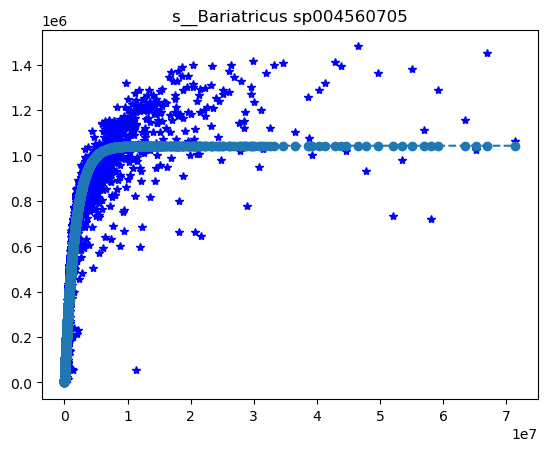

In [10]:
# test fit function!
name = NAMES[0]
print('fitting for:', NAMES[0])
species_df = manysearch_df.filter(pl.col("species") == NAMES[0]).sort(by='weighted_bp')

yfit, (G, C), r2 = do_fit(species_df)
print(f"fit params for {name}: G={G:.0f} C={C}; r2={r2:.3f}")
plt.plot(species_df['weighted_bp'], species_df['intersect_bp'], 'b*')
plt.plot(species_df['weighted_bp'], yfit, 'o--')
plt.title(name)

## Run fit function for all species, and record parameters.

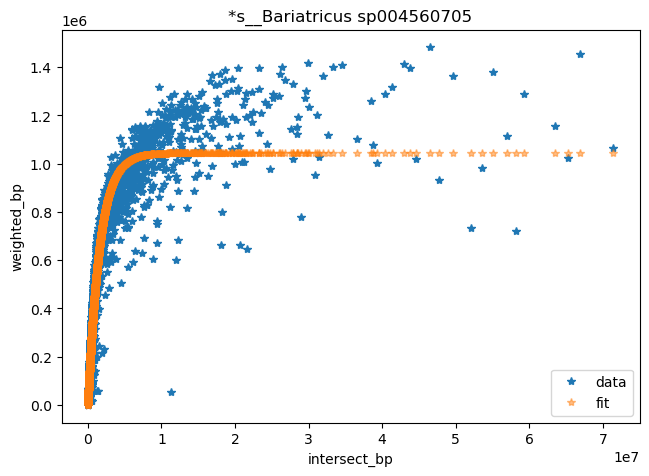

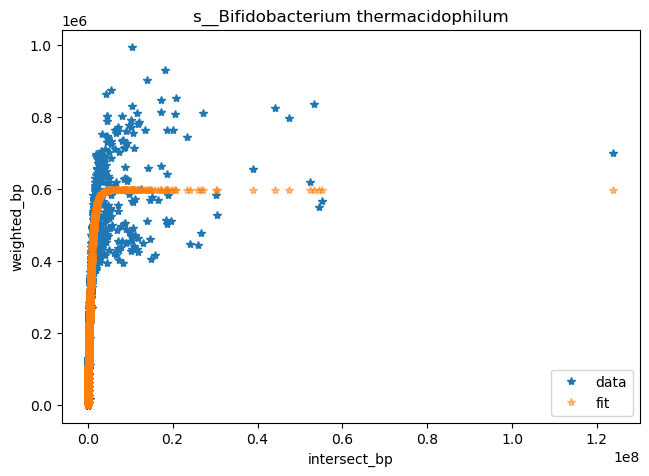

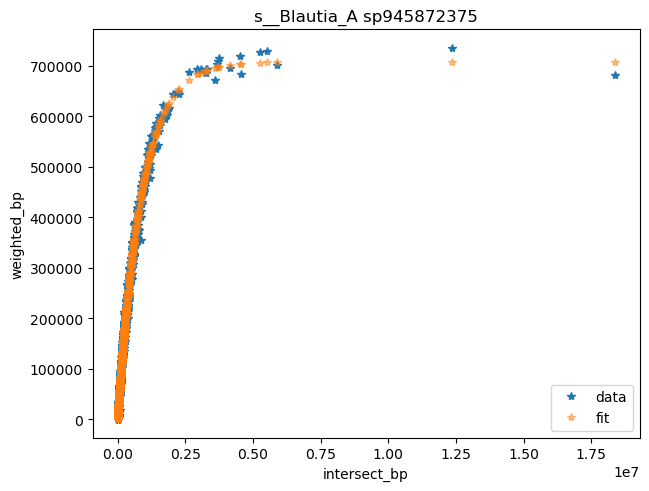

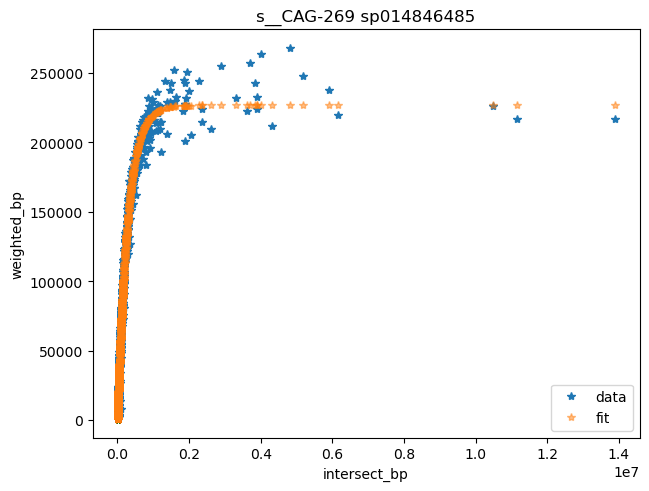

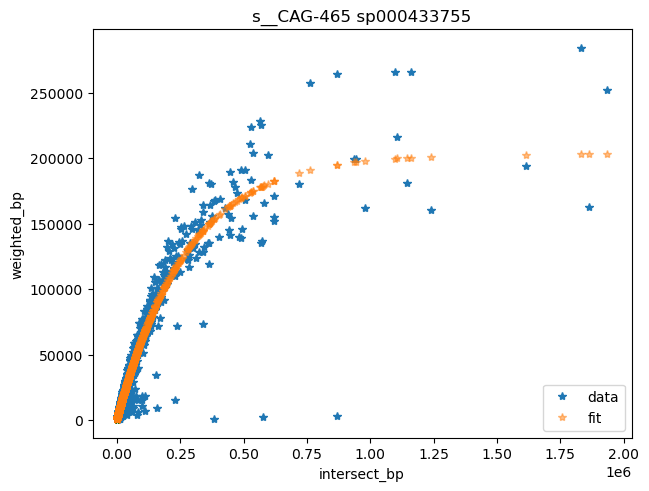

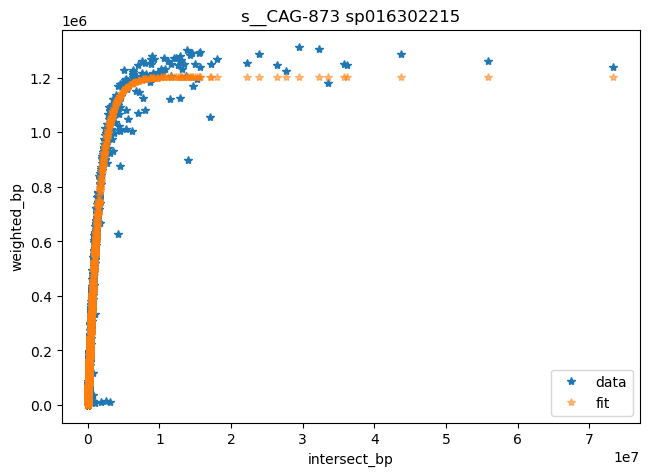

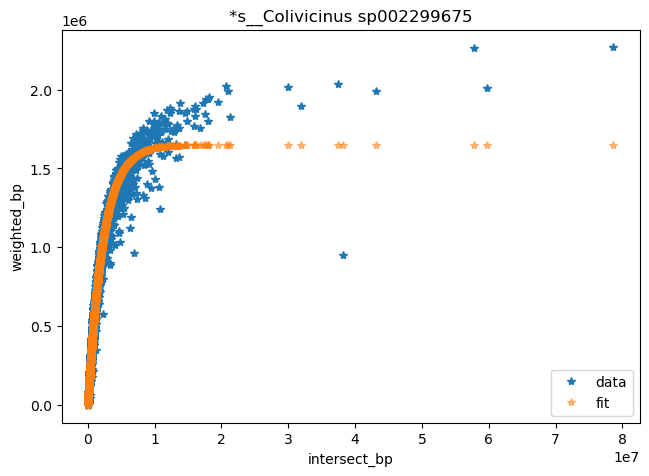

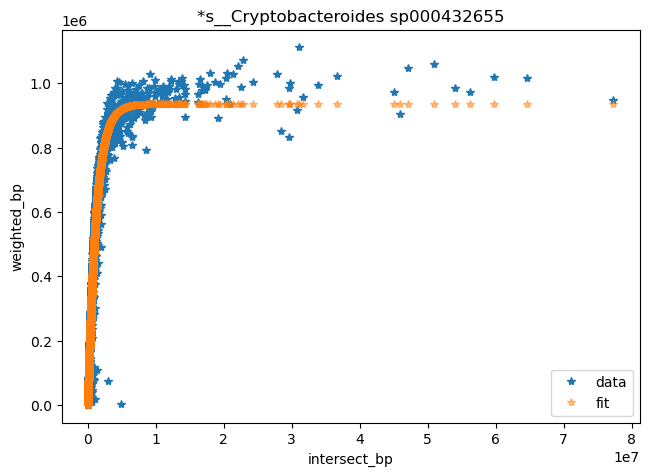

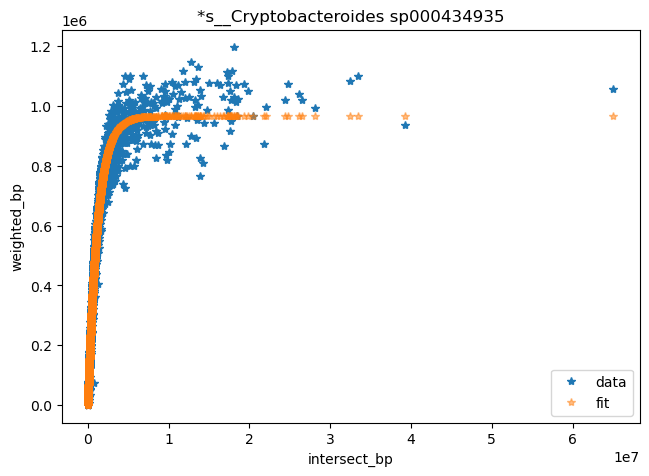

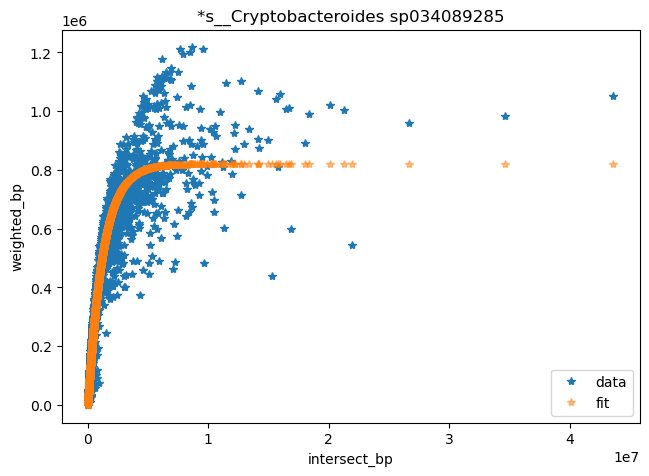

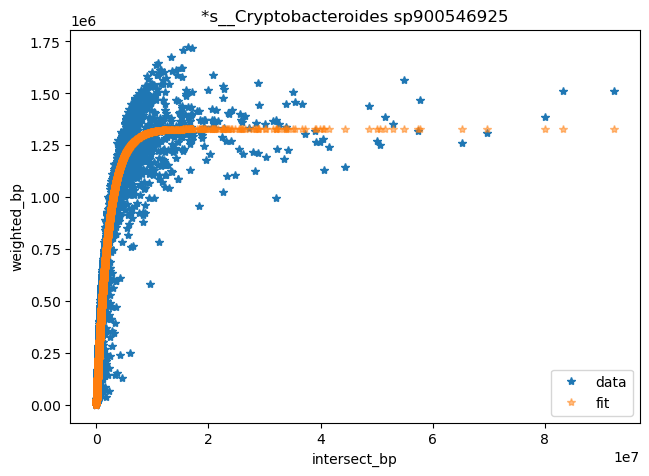

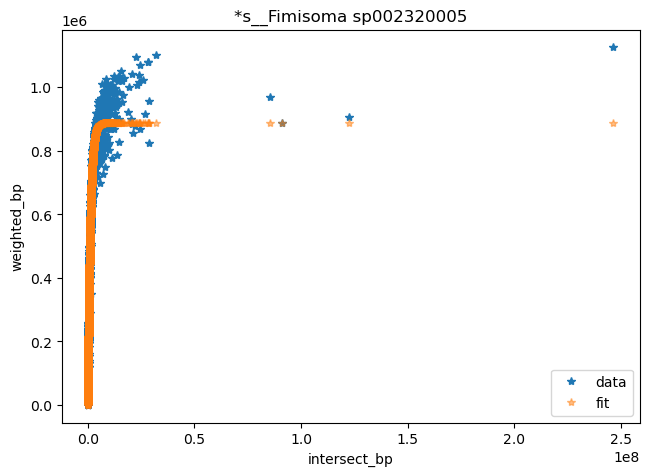

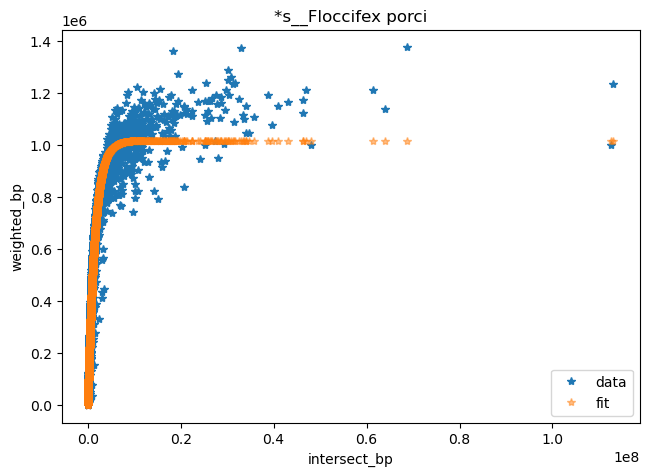

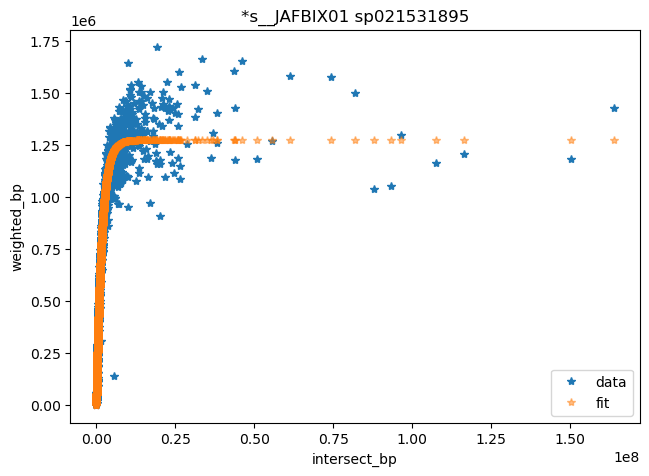

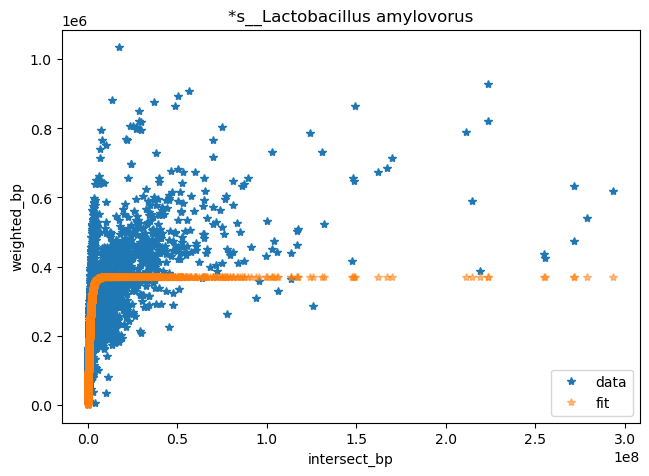

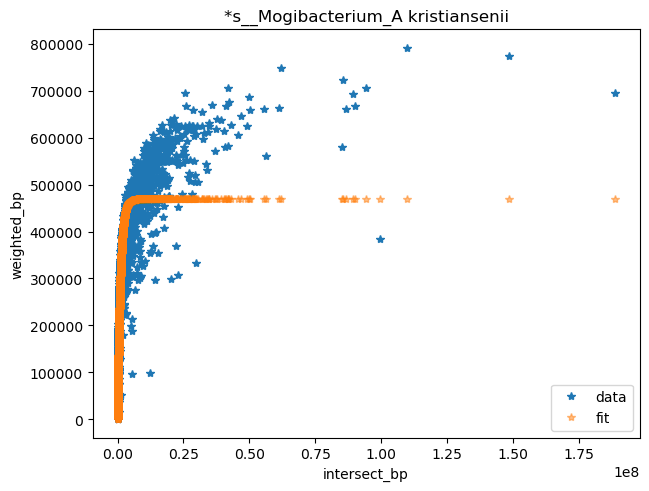

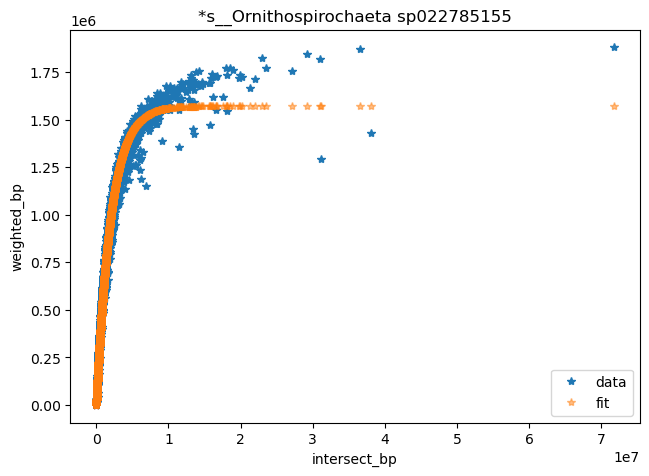

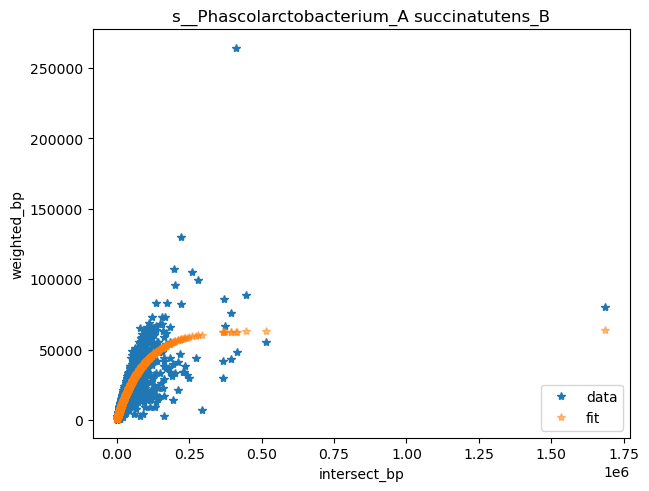

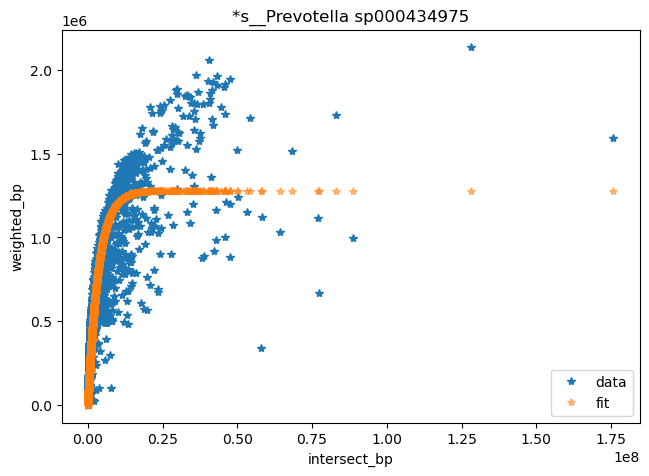

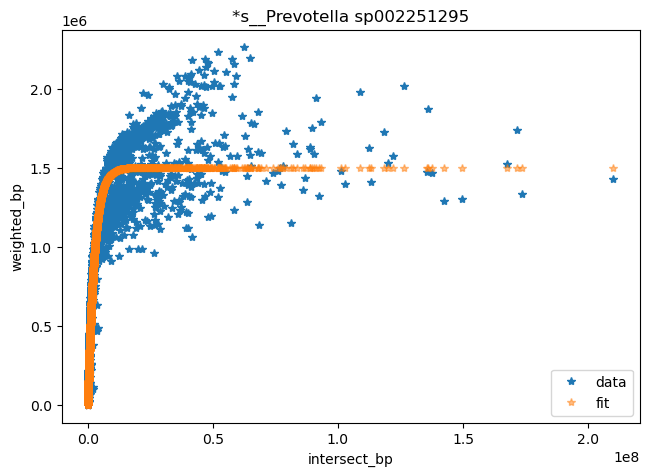

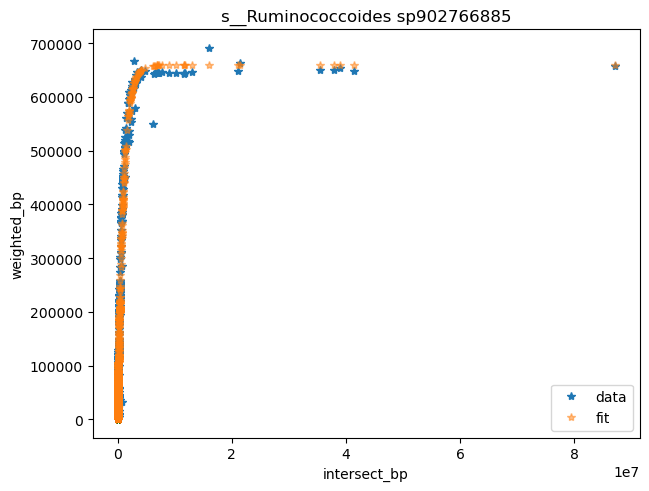

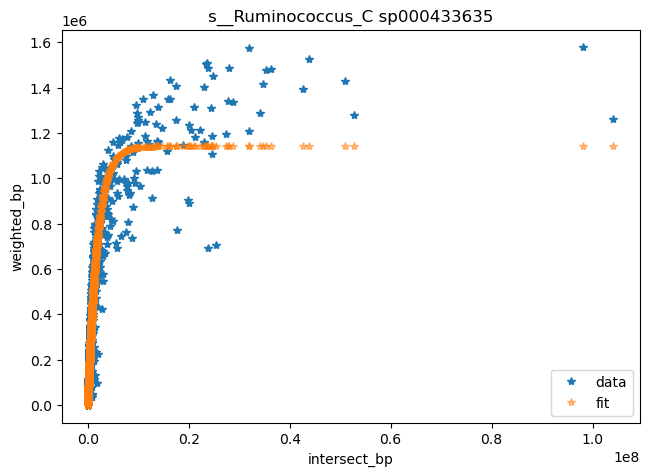

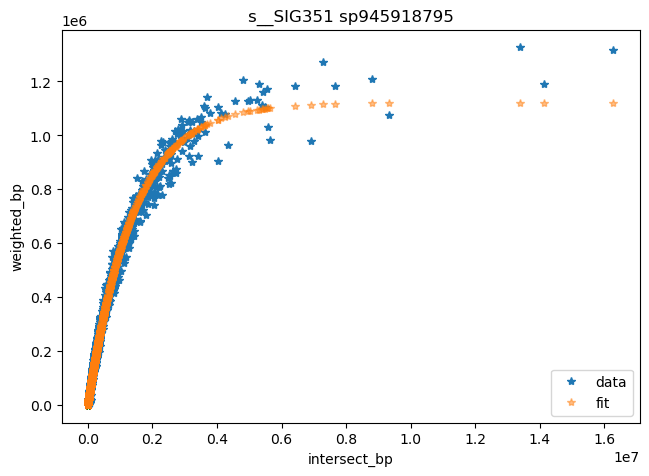

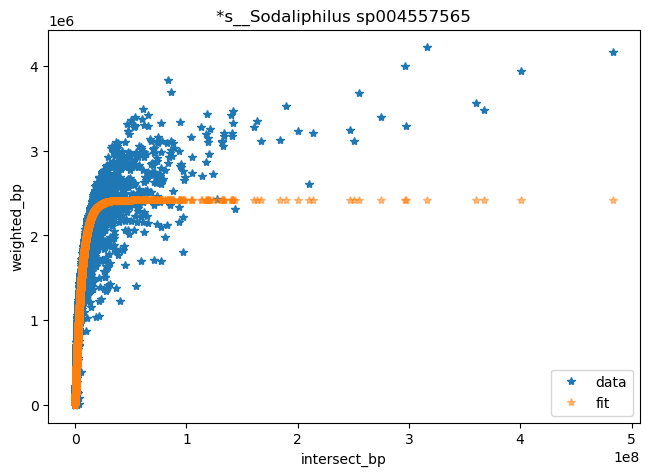

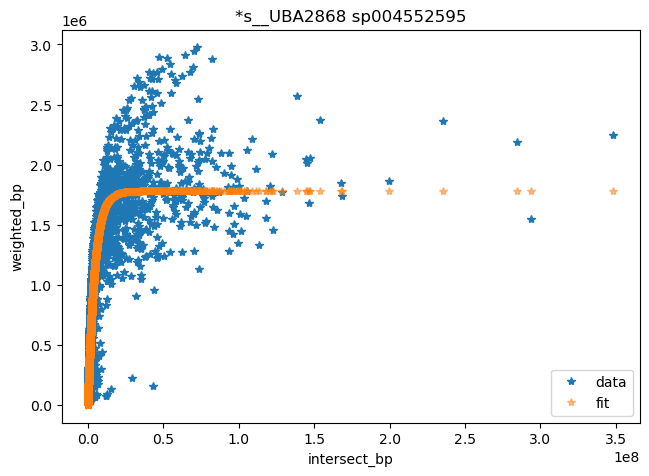

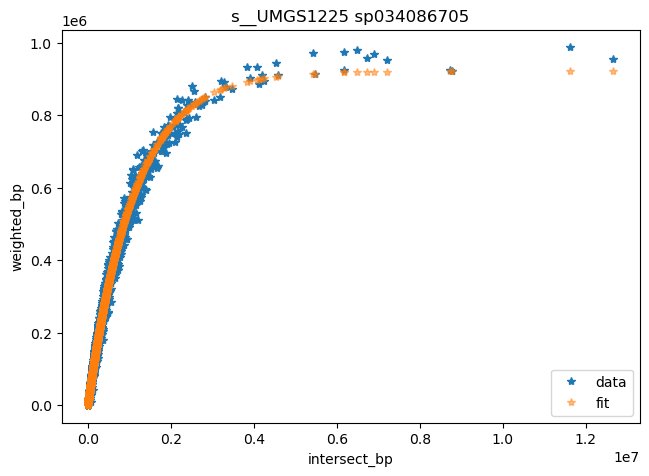

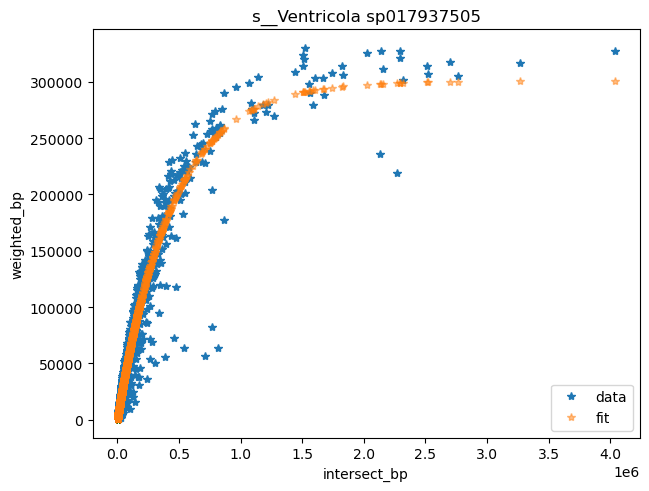

In [11]:
params_d = {}
params_df = []

for name in NAMES:
    species_df = manysearch_df.filter(pl.col("species") == name)
    yfit, params, r2 = do_fit(species_df)
    (GSIZE, CEXP) = params
    params_d[name] = (GSIZE, CEXP, r2)
    med = np.median(species_df['weighted_bp'] / GSIZE)
    q25 = np.percentile(species_df['weighted_bp'] / GSIZE, .25)
    num_metag = len(species_df.filter(pl.col("intersect_bp") > 20000))
#    print(f"{name:<50} {GSIZE / 1e6:.1f} Mbp    {med:.2f}        {EXP}")
    params_df.append(dict(name=name, med=med, gsize=GSIZE, exp=CEXP, num_metag=num_metag, r2=r2, q25=q25))

    plt.plot(species_df['weighted_bp'], species_df['intersect_bp'], '*', label='data')
    plt.plot(species_df['weighted_bp'], yfit, '*', alpha=0.5, label='fit')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('*' + name)
    else:
        plt.title(name)
    plt.xlabel('intersect_bp')
    plt.ylabel('weighted_bp')
    plt.legend(loc='lower right')

    #plt.xlim(0, 3)
    #plt.ylim(0, 1.5)
    plt.show()

params_df = pl.DataFrame(params_df)

In [12]:
print("species                                     med cov       q25           gsize")
for row in params_df.sort(by='med').iter_rows(named=True):
    name, med, gsize, num_metag, r2, q25 = row["name"], row["med"], row["gsize"], row["num_metag"], row["r2"], row['q25']
    print(f"{name:<45} {med:<10.2f}  {q25:<10.4f}   {gsize/1e6:.1f}Mbp     in {num_metag}    {r2:.3f}")

species                                     med cov       q25           gsize
s__CAG-873 sp016302215                        0.01        0.0008       1.2Mbp     in 1082    0.085
s__Ruminococcoides sp902766885                0.02        0.0015       0.7Mbp     in 602    0.035
s__Blautia_A sp945872375                      0.02        0.0014       0.7Mbp     in 1084    0.231
s__SIG351 sp945918795                         0.04        0.0009       1.1Mbp     in 1665    0.348
s__Bifidobacterium thermacidophilum           0.05        0.0017       0.6Mbp     in 1487    0.008
s__CAG-465 sp000433755                        0.05        0.0049       0.2Mbp     in 643    0.369
s__Ventricola sp017937505                     0.06        0.0033       0.3Mbp     in 1074    0.283
s__CAG-269 sp014846485                        0.06        0.0044       0.2Mbp     in 905    0.075
s__Ruminococcus_C sp000433635                 0.07        0.0009       1.1Mbp     in 1825    0.041
s__UMGS1225 sp034086705           

## Update with a new fit function that we have an estimated genome size

We can now adjust 'x' by the estimated size of the (pan) genome, for each species.

Read through [the inStrain docs](https://instrain.readthedocs.io/en/latest/important_concepts.html) for some interesting context -
the coverage parameter should be ~0.88 for a full genome.

In [13]:
# try with adjusted coverage, where we divide 'x' by tbe estimated genome size
params2_d = {}
for name in NAMES:
    species_df = manysearch_df.filter(pl.col("species") == name)
    GSIZE, EXP, r2 = params_d[name]

    def adj_coverage_curve(x, c, e):
        return c*(1 - np.exp(-e*x/GSIZE))

    p0 = (max(species_df['weighted_bp']), 0.9)
    _, params2, _ = do_fit(species_df, fn=adj_coverage_curve, p0=p0)
    NORM, EXP2 = params2
    print(f"{name:<50} {NORM:<10.0f} {EXP2:2f}")
    params2_d[name] = params2

s__Bariatricus sp004560705                         1043046    0.645250
s__Bifidobacterium thermacidophilum                596538     0.728500
s__Blautia_A sp945872375                           707929     0.800124
s__CAG-269 sp014846485                             226746     0.792968
s__CAG-465 sp000433755                             203208     0.744784
s__CAG-873 sp016302215                             1202798    0.762858
s__Colivicinus sp002299675                         1648882    0.721022
s__Cryptobacteroides sp000432655                   934653     0.771361
s__Cryptobacteroides sp000434935                   965961     0.799445
s__Cryptobacteroides sp034089285                   819658     0.652647
s__Cryptobacteroides sp900546925                   1327159    0.613436
s__Fimisoma sp002320005                            887900     0.771211
s__Floccifex porci                                 1016431    0.681308
s__JAFBIX01 sp021531895                            1272598    0.728966
s__Lac

In [14]:
# use the new information to estimate breadth and depth for every row, and then add into data frame.
adj_df = []

for row in manysearch_df.iter_rows(named=True):
    species = row["species"]
    metag = row["metag"]
    intersect_bp = row["intersect_bp"]
    weighted_bp = row["weighted_bp"]
    GSIZE, EXP, r2 = params_d[species]
    breadth = intersect_bp / GSIZE
    depth = weighted_bp / GSIZE
    fit_breadth = coverage_curve(weighted_bp, GSIZE, EXP) / GSIZE
    adj_df.append(dict(species=species, metag=metag, breadth=breadth, depth=depth, fit_breadth=fit_breadth))

adj_df = pl.DataFrame(adj_df)
join_df = manysearch_df.join(adj_df, on=['species', 'metag'], how='inner')
join_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size,intersect_bp,weighted_bp,breadth,depth,fit_breadth
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64,i64,i64,f64,f64,f64
"""s__Cryptobacteroides sp0004326…","""33ab318886b78679c8de5e106ac6b9…","""SRR11125436""",0.045958,191,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000536,0.045958,1.356021,1.0,0.744229,0.86358,0.698971,0.781276,0.86358,259,950458,"""s__Cryptobacteroides sp0004326…","""SRR11125436""",4.156e6,191000,259000,0.204354,0.277108,0.19245
"""s__Bariatricus sp004560705""","""a053514b987f8c11e2ed518938e366…","""SRR11125436""",0.127554,387,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.001089,0.127554,1.757106,1.0,1.189063,0.906597,0.722874,0.814735,0.906597,680,950458,"""s__Bariatricus sp004560705""","""SRR11125436""",3.034e6,387000,680000,0.371028,0.651935,0.343385
"""s__Floccifex porci""","""d517f763cae95c3706b3311e9ef0ca…","""SRR11125436""",0.071151,165,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000465,0.071151,1.569697,1.0,1.192015,0.881743,0.694117,0.78793,0.881743,259,950458,"""s__Floccifex porci""","""SRR11125436""",2.319e6,165000,259000,0.162333,0.254813,0.159372
"""s__Cryptobacteroides sp0340892…","""376b4bdd83505f2f45acbe381d3914…","""SRR11125436""",0.097169,254,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000715,0.097169,1.767717,1.0,1.165946,0.894926,0.708524,0.801725,0.894926,449,950458,"""s__Cryptobacteroides sp0340892…","""SRR11125436""",2.614e6,254000,449000,0.309885,0.547788,0.300585
"""s__Prevotella sp000434975""","""4736bc318783e81245554ed9fa261a…","""SRR11125436""",0.001619,11,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000031,0.001619,1.090909,1.0,0.28748,0.73639,0.610139,0.673264,0.73639,12,950458,"""s__Prevotella sp000434975""","""SRR11125436""",6.794e6,11000,12000,0.008607,0.009389,0.003399
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Colivicinus sp002299675""","""751a24e45a6cdebaf4daf12fd0f355…","""ERR8314784""",0.382275,1294,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",0.000483,0.382275,2.958269,2.0,2.231873,0.955241,0.695173,0.825207,0.955241,3828,11178711,"""s__Colivicinus sp002299675""","""ERR8314784""",3.385e6,1294000,3828000,0.784773,2.321568,0.812484
"""s__CAG-269 sp014846485""","""078c4569f257f75356832c47c16808…","""ERR8314784""",0.002294,1,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",3.7320e-7,0.002294,1.0,1.0,0.0,0.748704,0.494203,0.621453,0.748704,1,11178711,"""s__CAG-269 sp014846485""","""ERR8314784""",436000.0,1000,1000,0.00441,0.00441,0.003491
"""s__UMGS1225 sp034086705""","""32711230ebb0936ab57ed263368289…","""ERR8314784""",0.051258,55,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",0.000021,0.051258,1.272727,1.0,0.645391,0.868081,0.598108,0.733094,0.868081,70,11178711,"""s__UMGS1225 sp034086705""","""ERR8314784""",1.073e6,55000,70000,0.059676,0.075952,0.061348


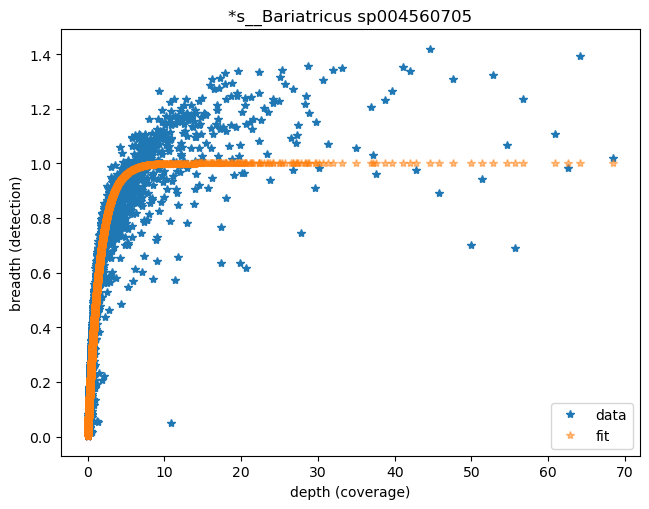

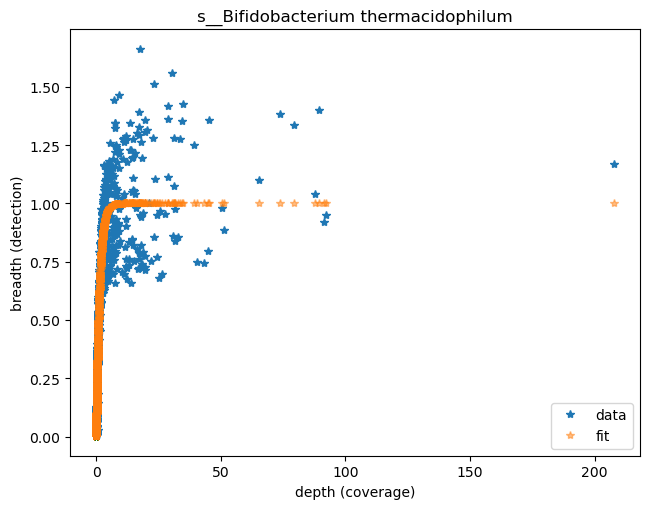

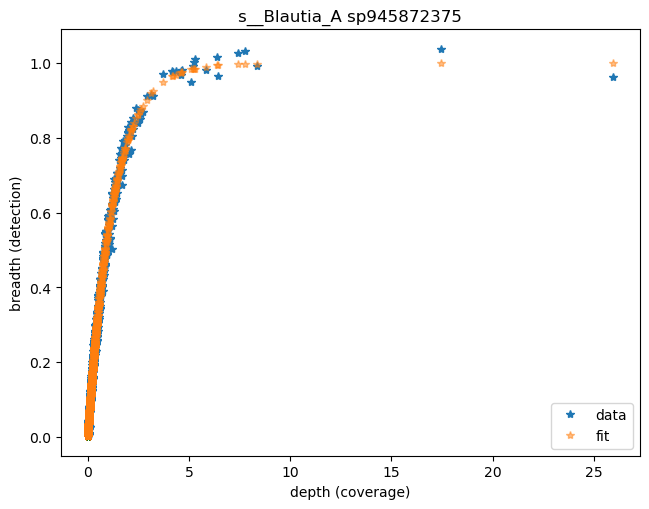

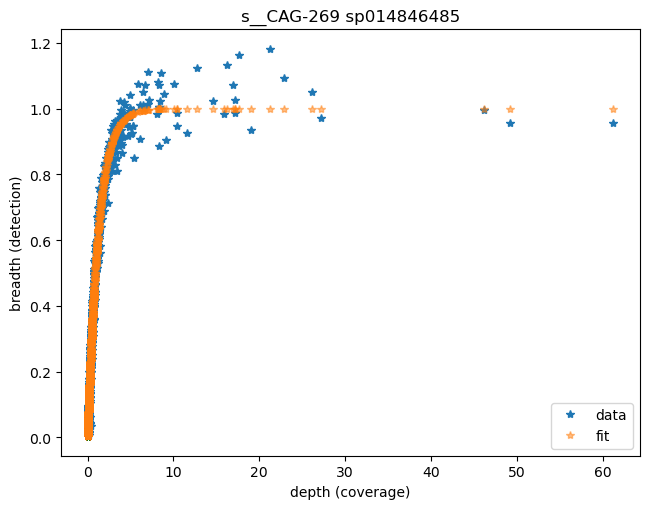

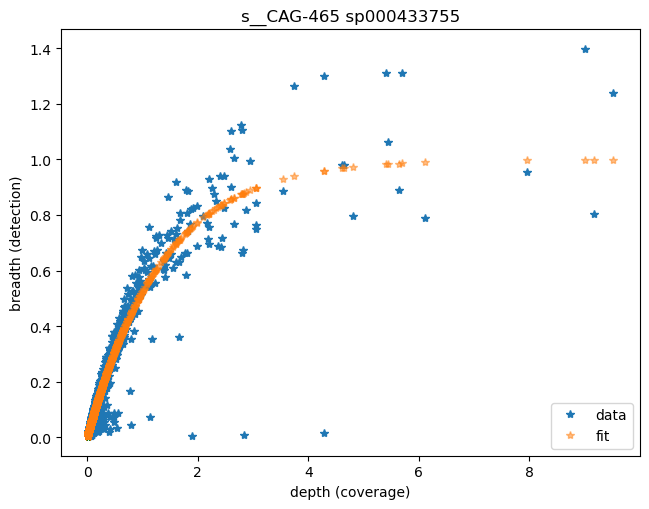

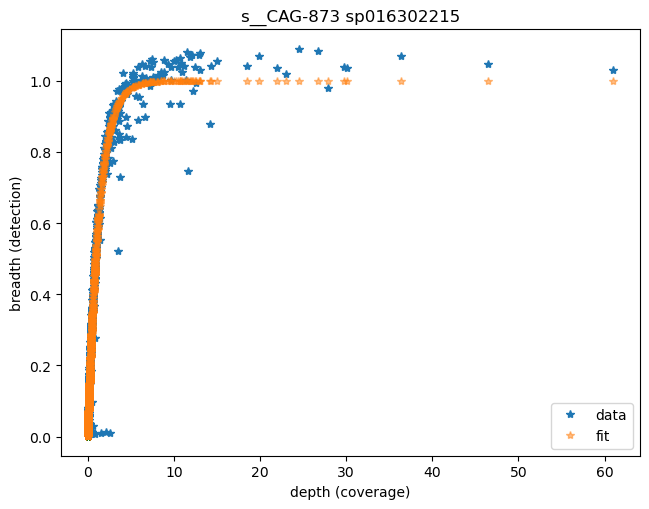

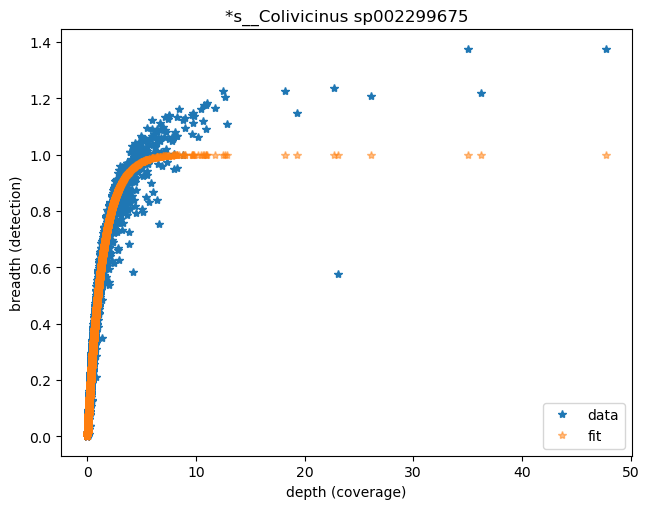

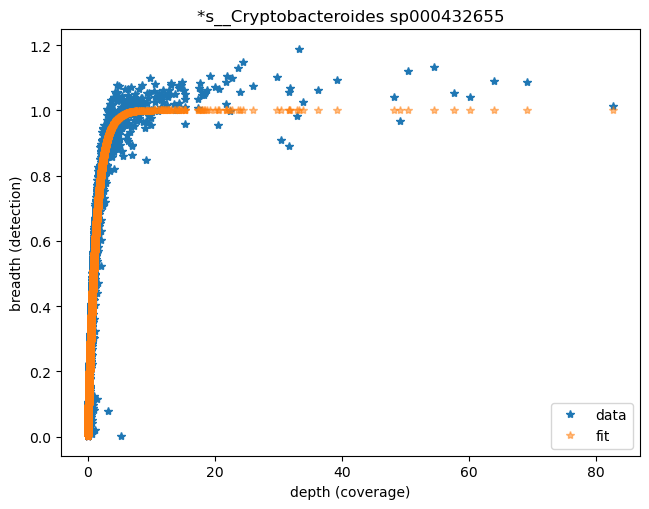

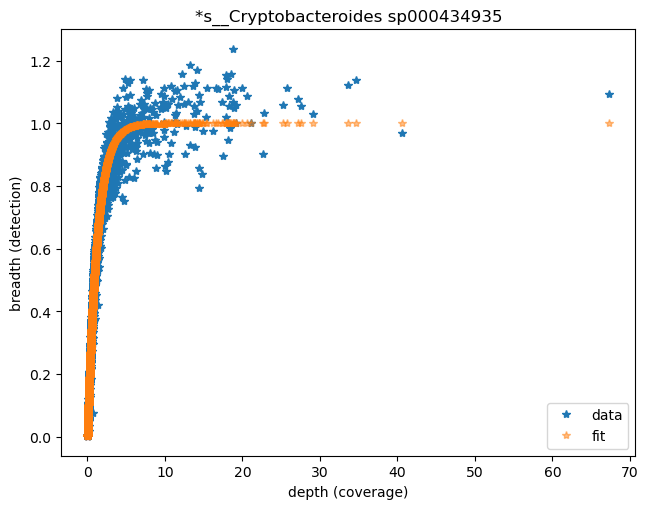

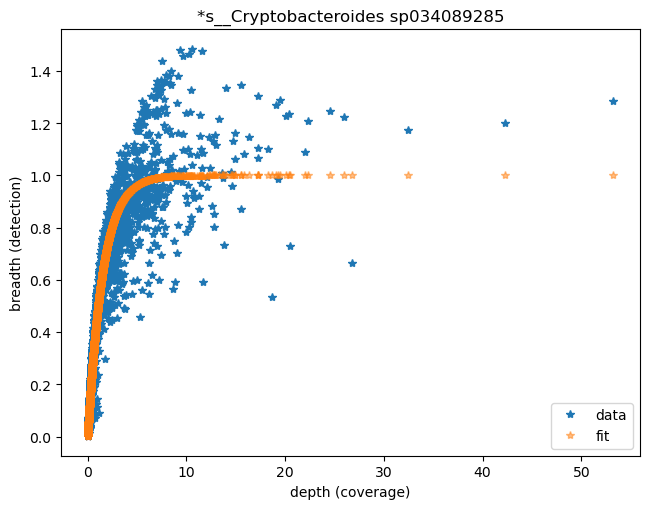

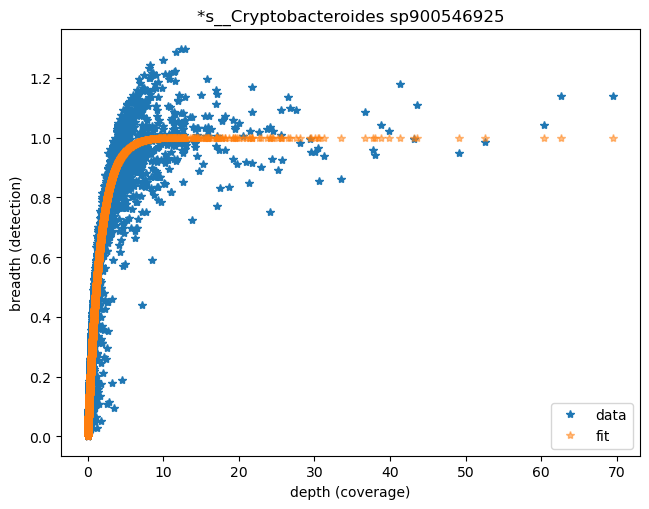

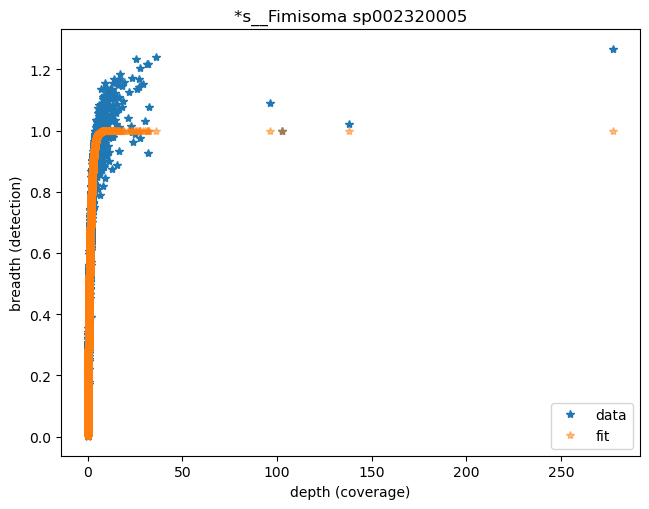

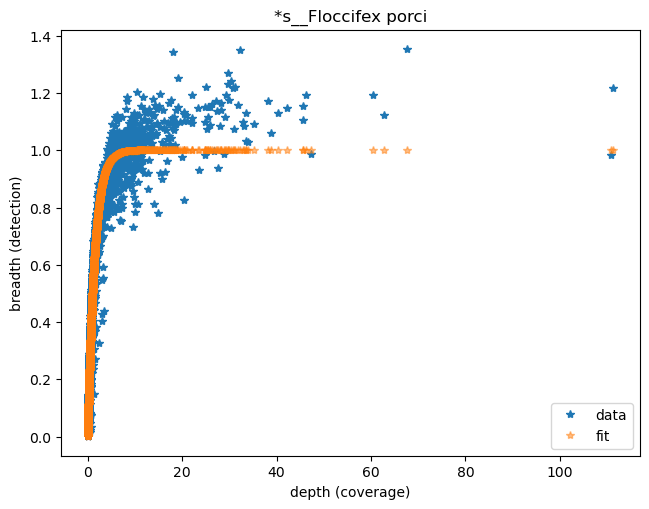

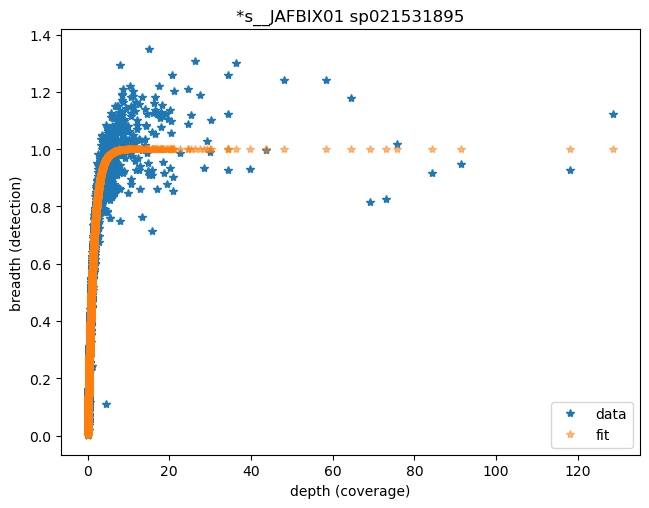

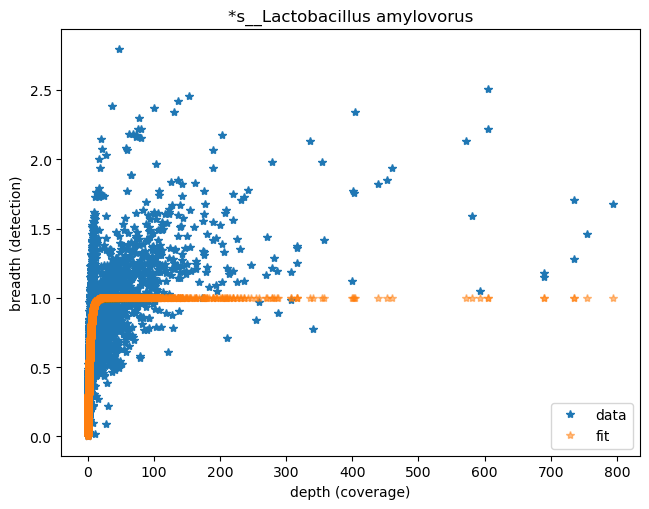

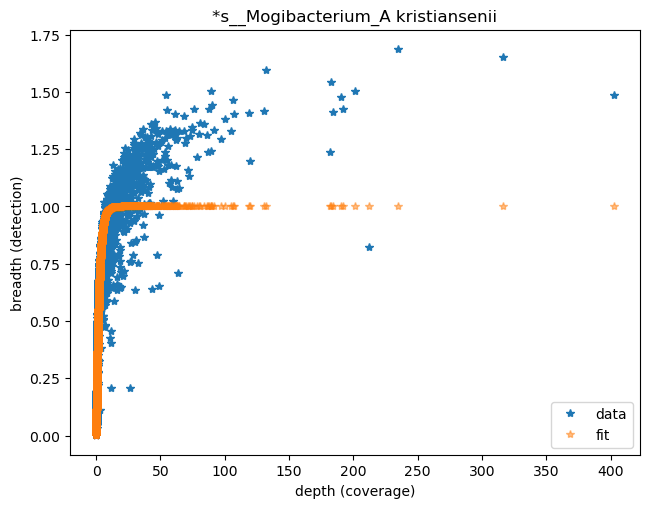

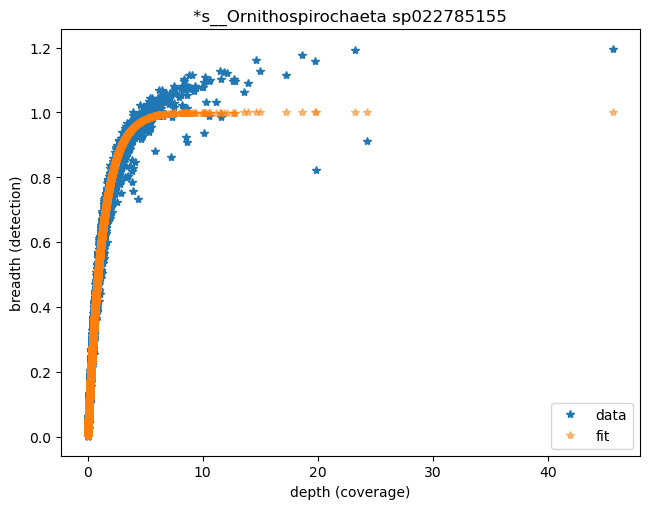

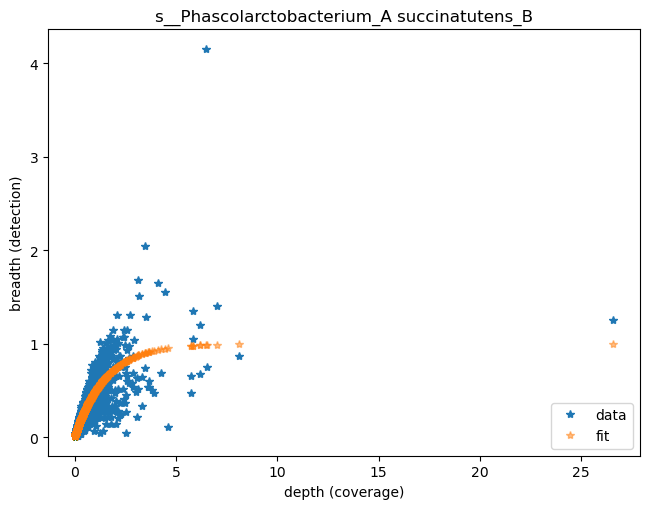

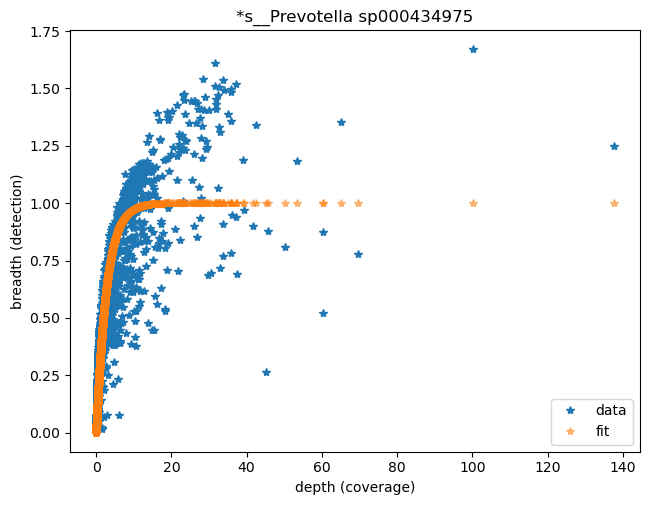

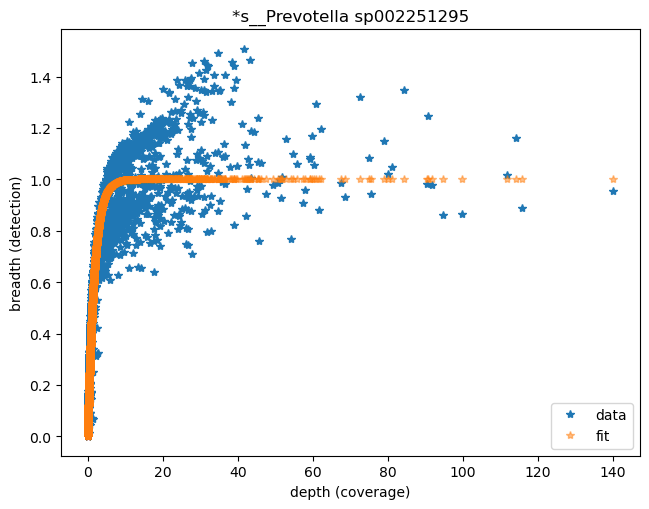

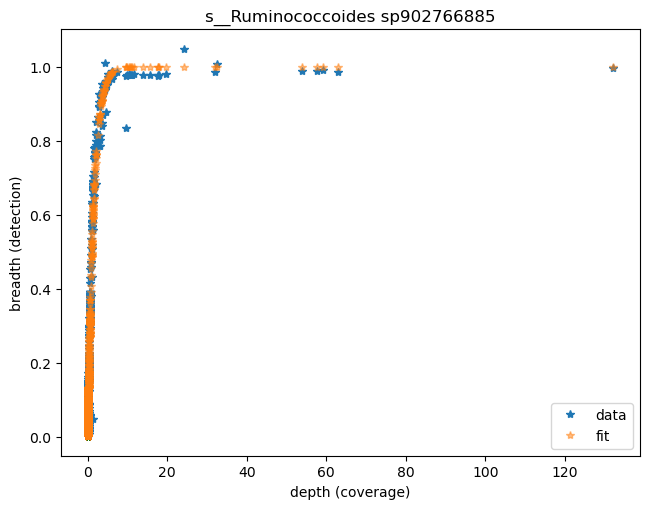

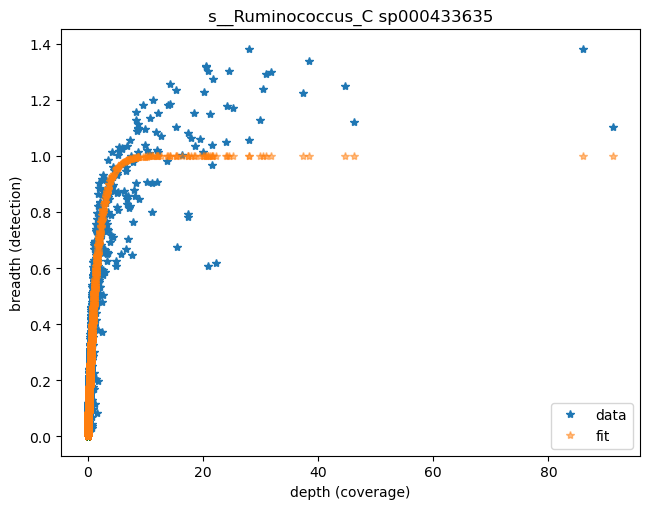

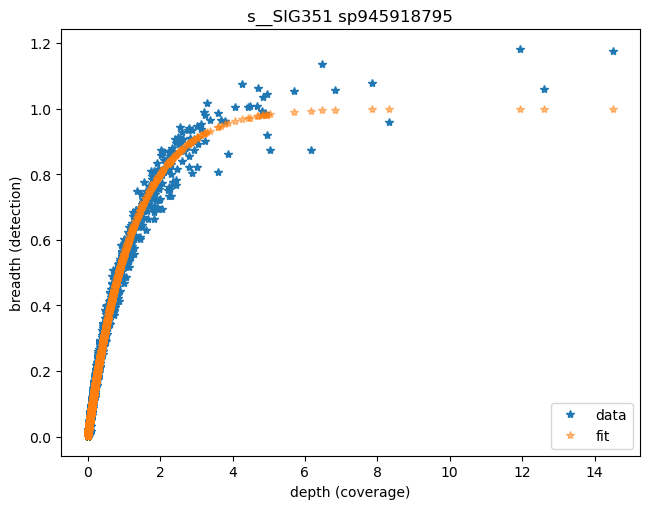

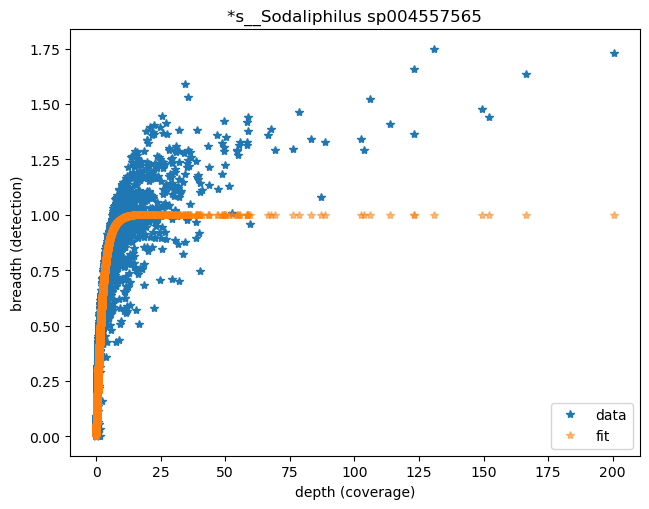

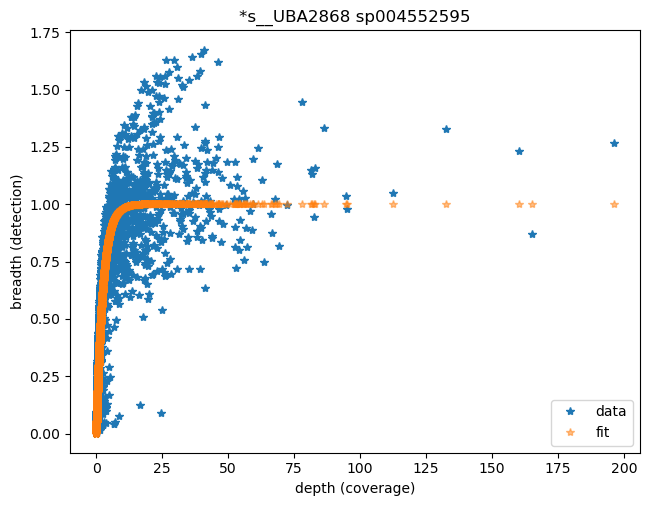

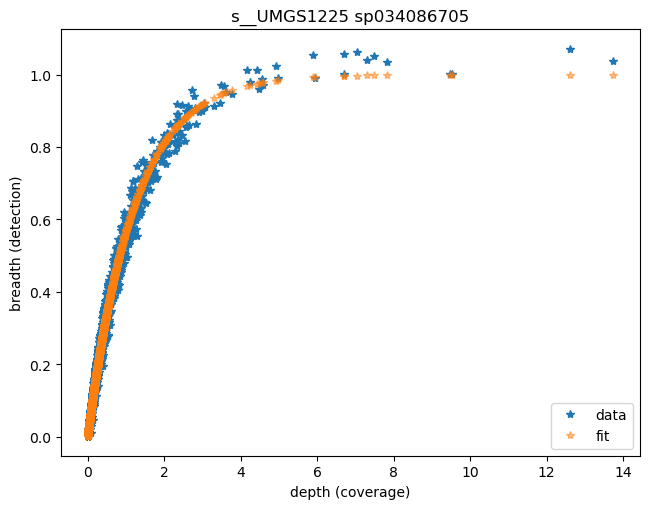

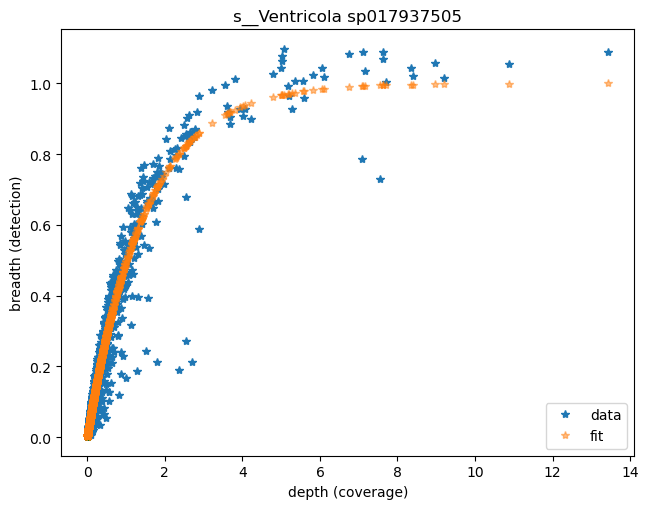

In [15]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)

    plt.plot(species_df['depth'], species_df['breadth'], '*', label='data')
    plt.plot(species_df['depth'], species_df['fit_breadth'], '*', alpha=0.5, label='fit')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('*' + name)
    else:
        plt.title(name)
    plt.xlabel('depth (coverage)')
    plt.ylabel('breadth (detection)')
    plt.legend(loc='lower right')

    #plt.xlim(0, 3)
    #plt.ylim(0, 1.5)
    plt.show()


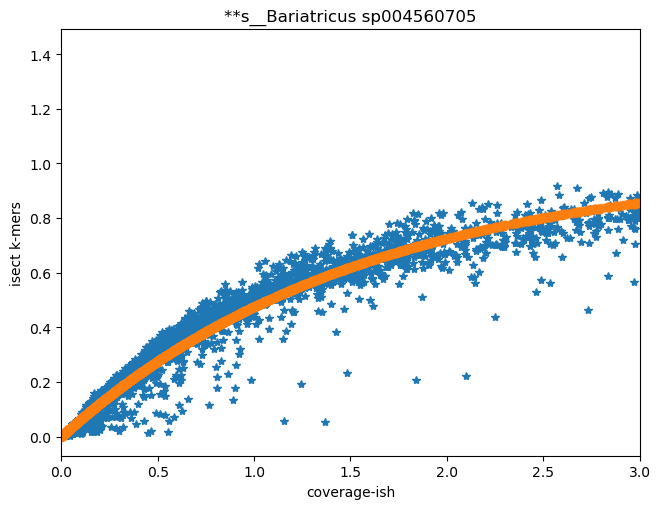

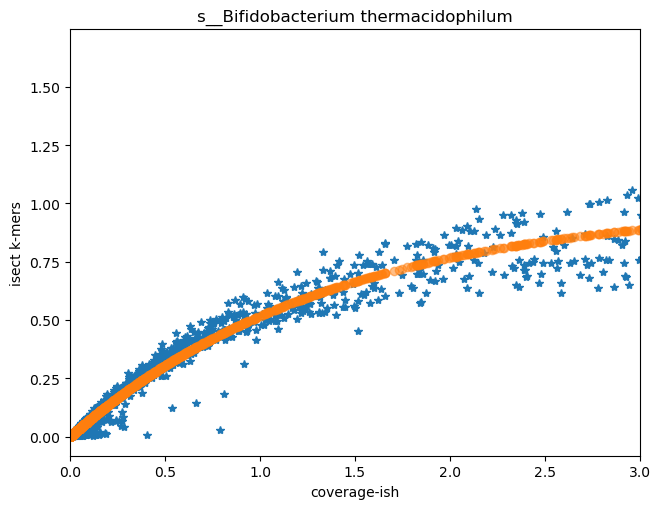

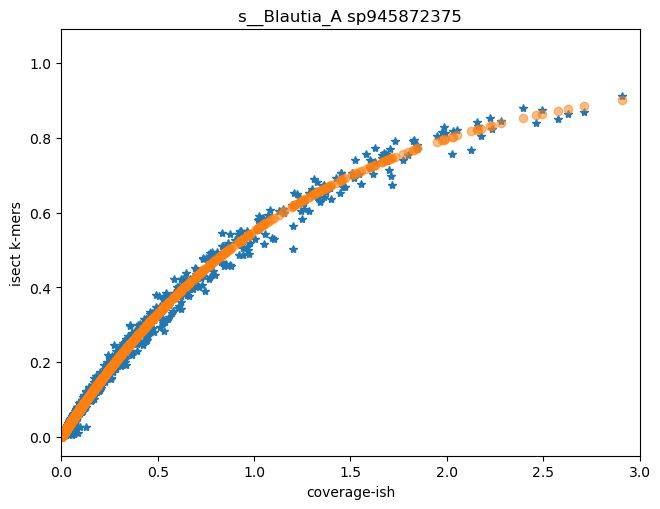

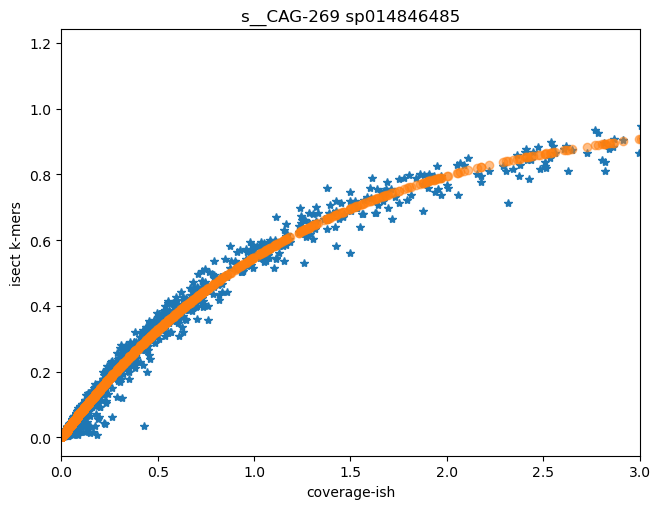

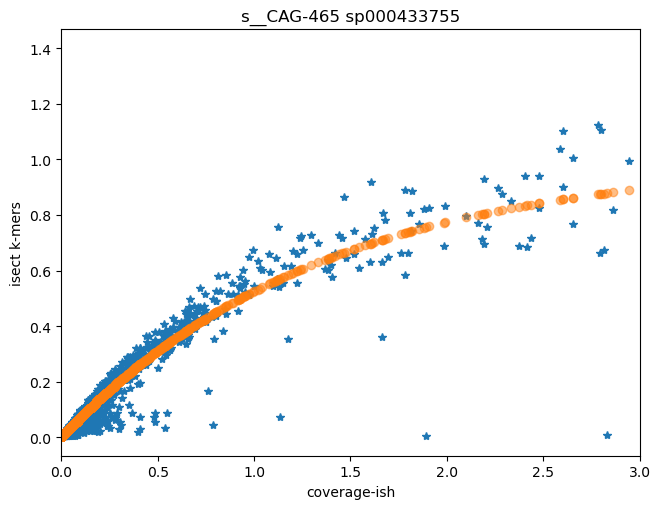

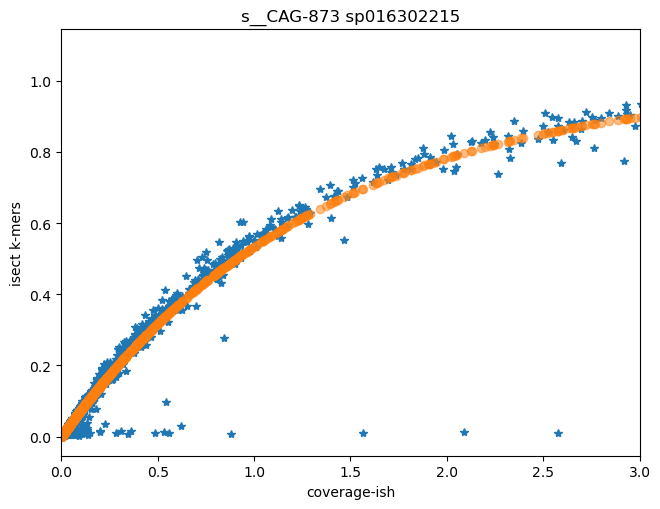

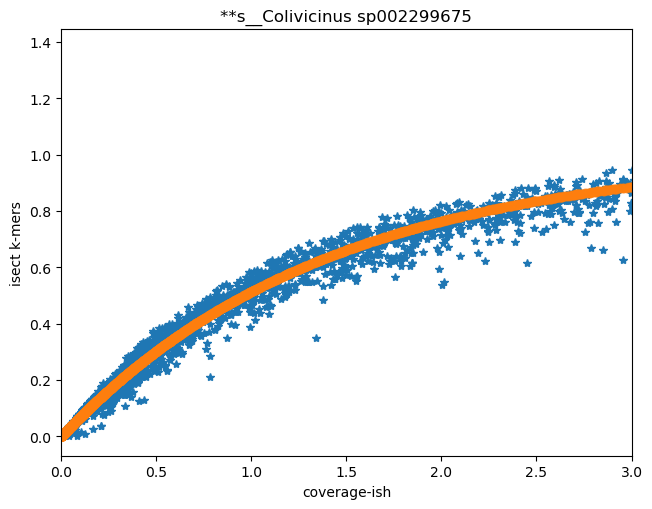

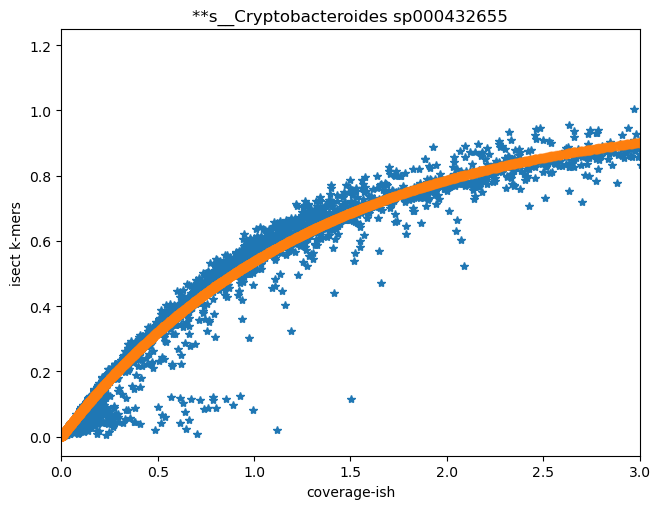

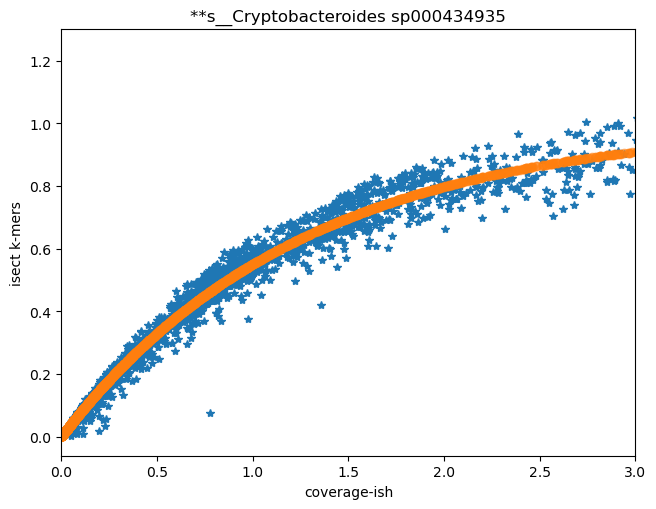

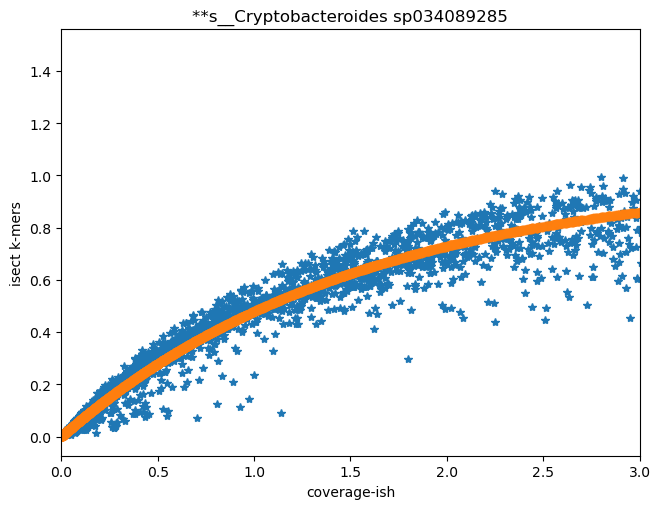

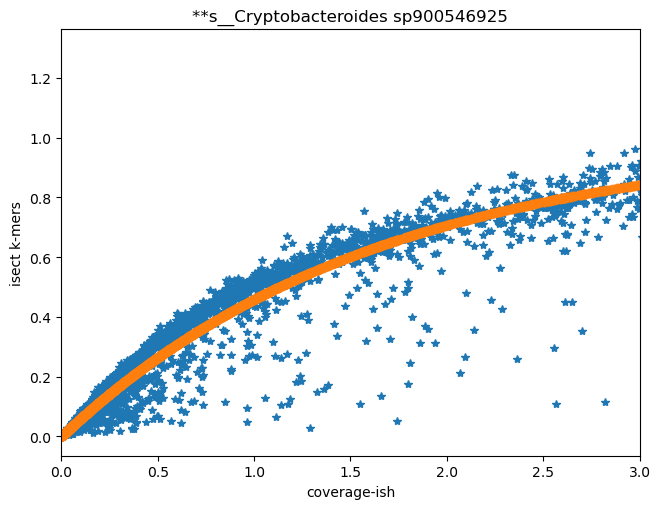

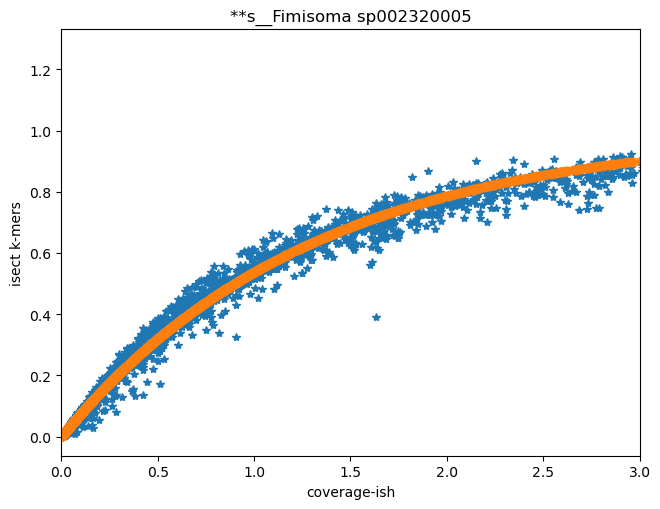

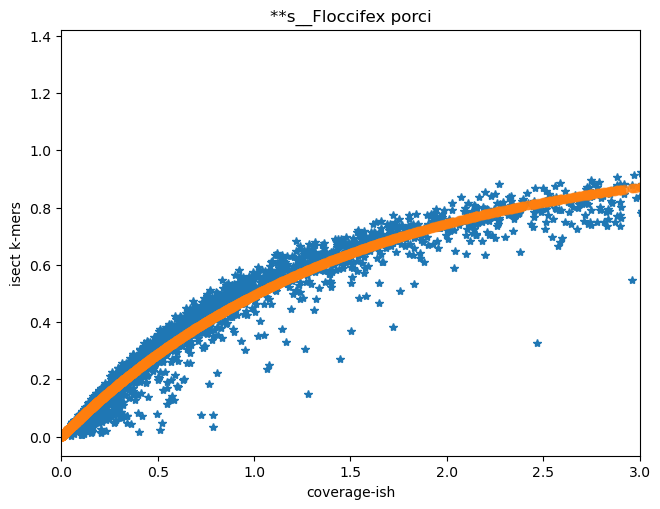

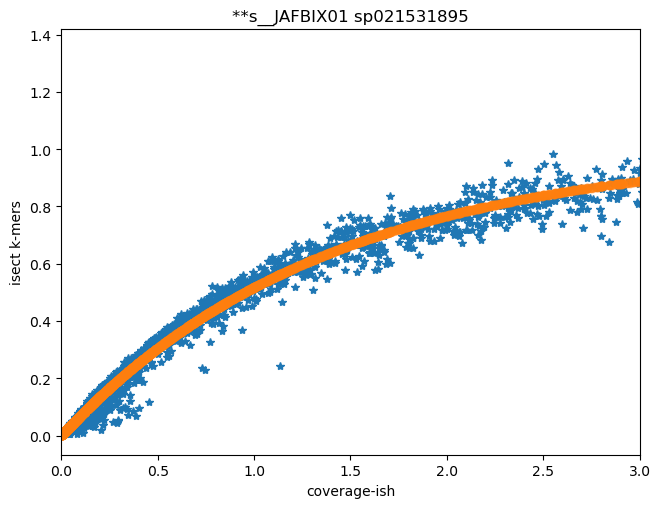

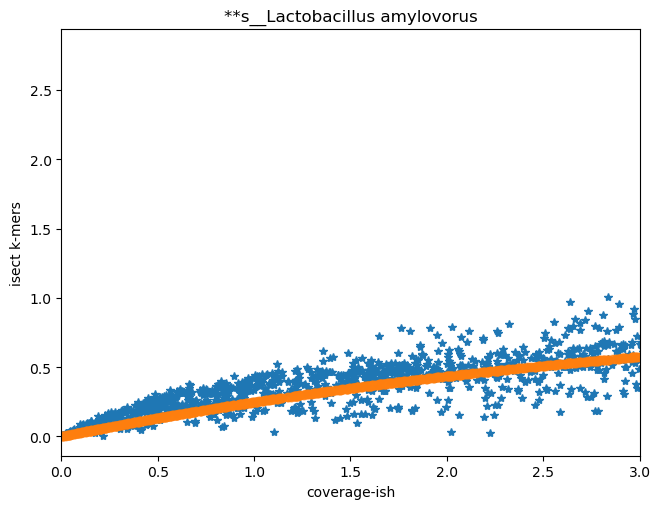

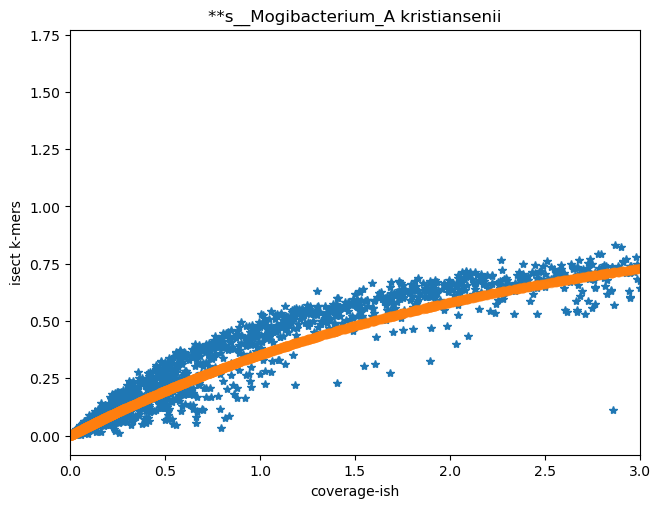

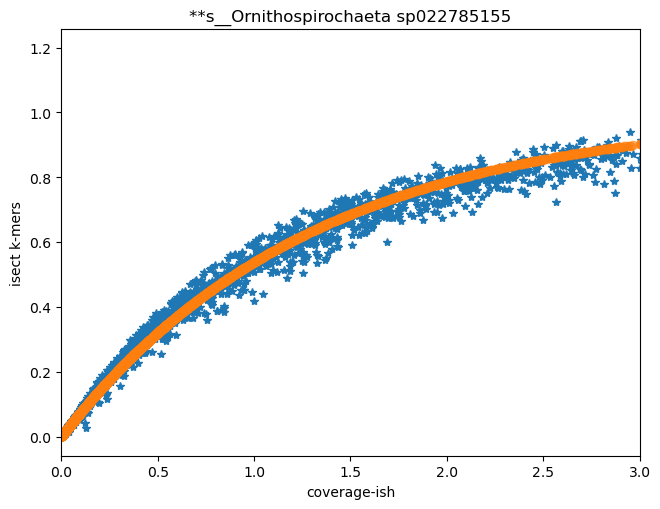

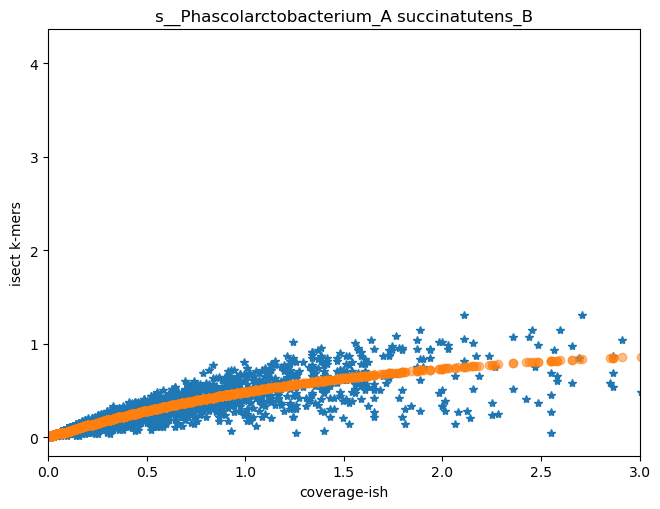

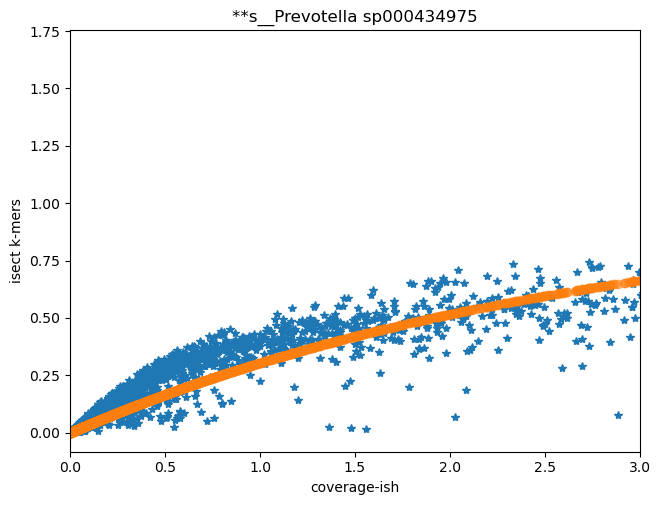

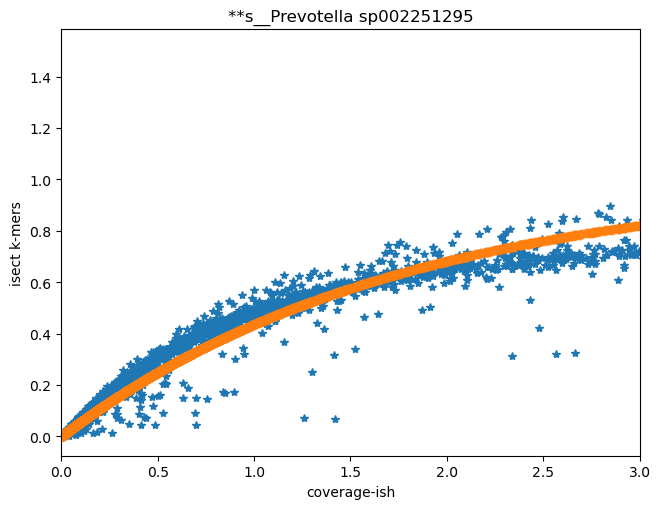

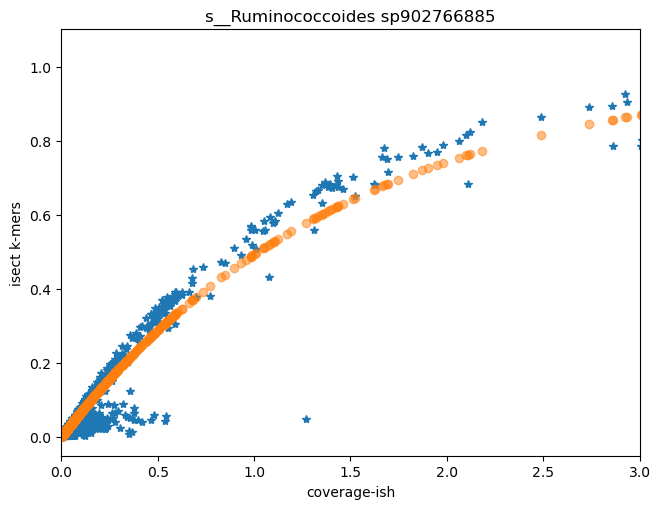

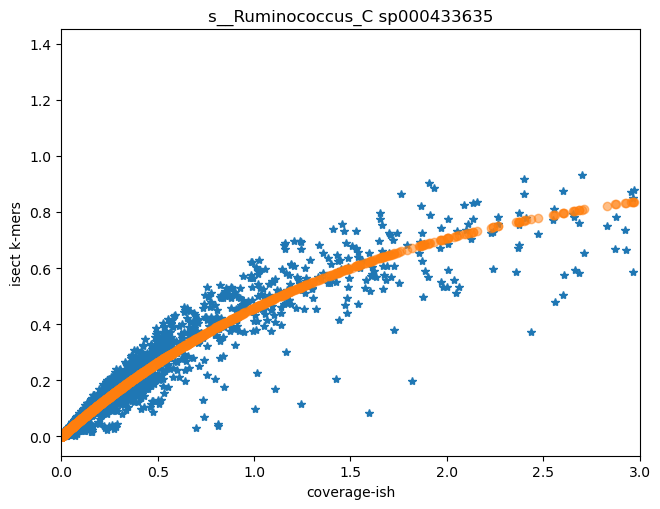

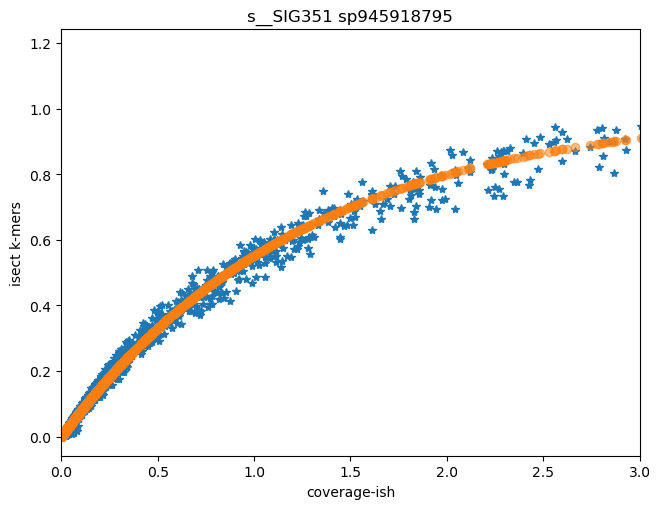

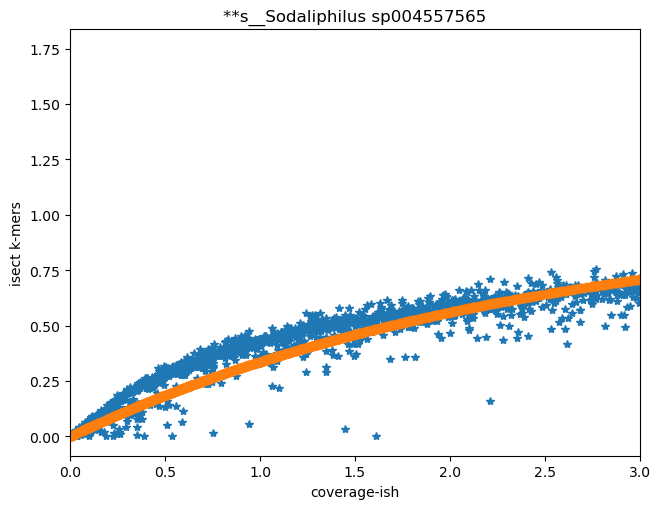

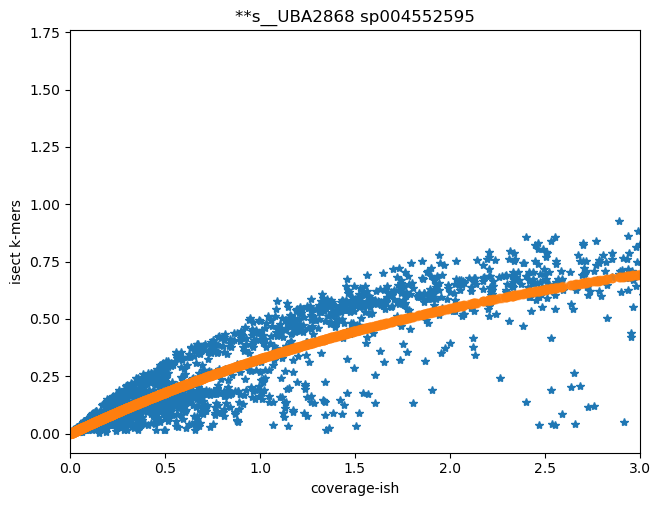

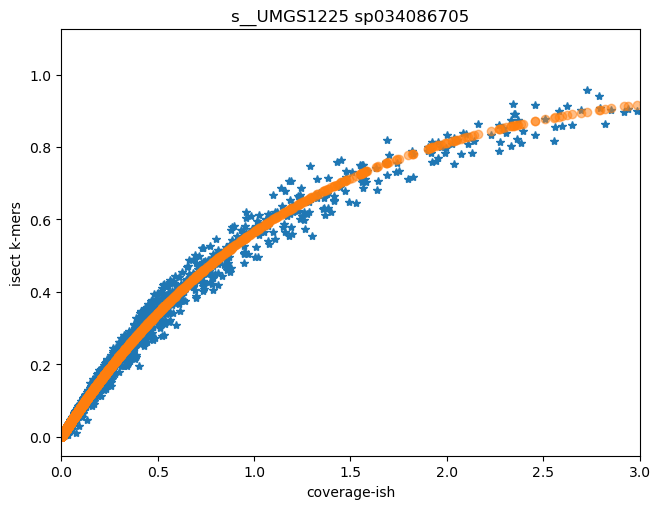

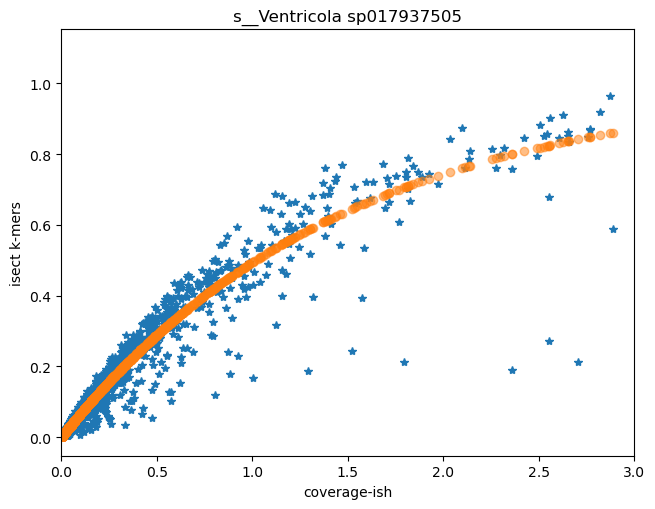

In [16]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)
    GSIZE, EXP, r2 = params_d[name]

    plt.plot(species_df['weighted_bp'] / GSIZE, species_df['intersect_bp'] / GSIZE, '*')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlabel('coverage-ish')
    plt.ylabel('isect k-mers')

    yfit = coverage_curve(species_df['weighted_bp'], GSIZE, EXP)
    plt.plot(species_df['weighted_bp'] / GSIZE, yfit / GSIZE, 'o', alpha=0.5)
    plt.xlim(0, 3)
    plt.show()


### Export / save k-mer coverage information

In [17]:
join_df.write_csv('../outputs.cds/kmer-coverage.csv')

## Can we correlate with metagenome sequencing depth?

Answer: no, not really. Presumably biology is involved (that is, actual abundance of microbes is different in different metagenomes!)

In [18]:
metadata_df = pl.scan_parquet('/group/ctbrowngrp5/sra-metagenomes/20241128-metadata.parquet')
metadata_df = metadata_df.select(["acc", "organism", "assay_type", "mbases"])\
    .filter(pl.col("acc") != "NP")\
    .filter(pl.col("assay_type") == "WGS")

metadata_df = metadata_df.collect()
metadata_df

acc,organism,assay_type,mbases
str,str,str,i64
"""SRR28523869""","""human metagenome""","""WGS""",258
"""SRR19901137""","""Streptococcus suis""","""WGS""",40
"""SRR24962475""","""Escherichia coli""","""WGS""",88
"""SRR29161330""","""biofilm metagenome""","""WGS""",3
"""SRR26668739""","""bovine gut metagenome""","""WGS""",129
…,…,…,…
"""ERR4174288""","""human gut metagenome""","""WGS""",1017
"""ERR3160109""","""human gut metagenome""","""WGS""",133
"""ERR2709457""","""human gut metagenome""","""WGS""",964


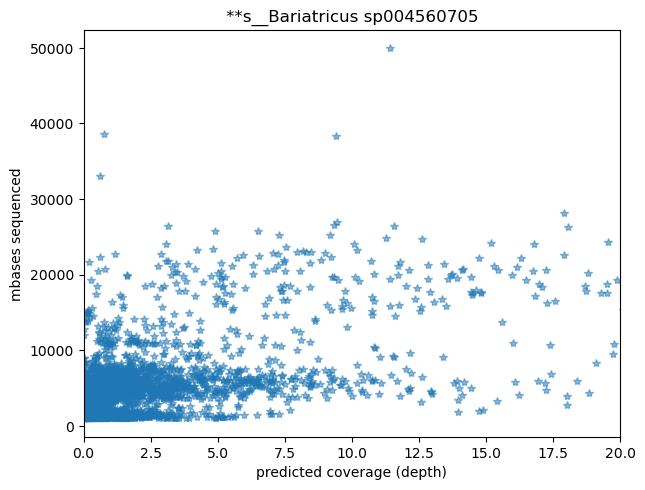

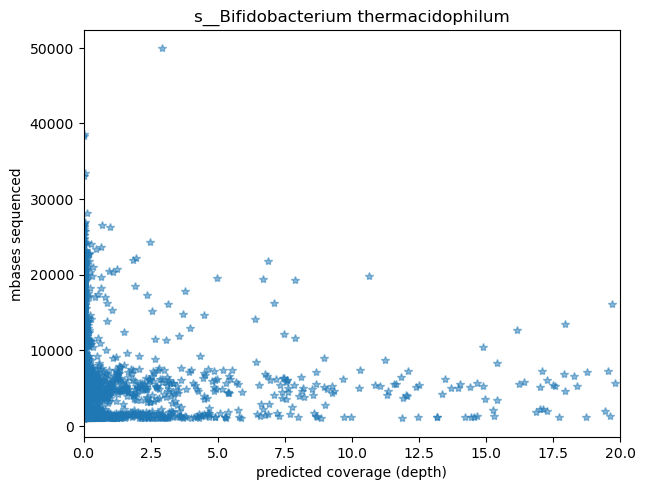

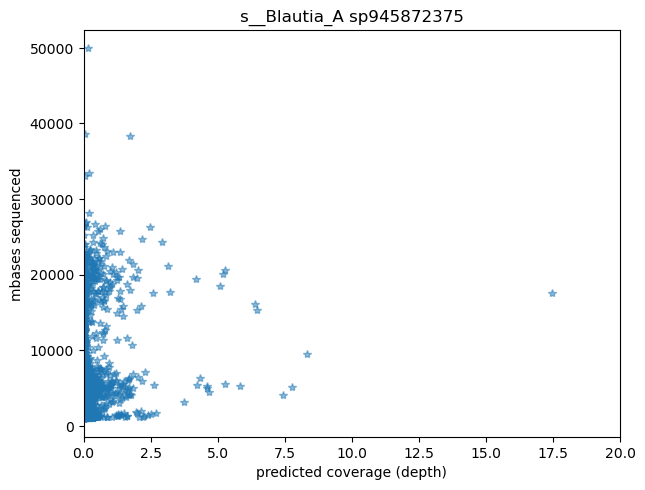

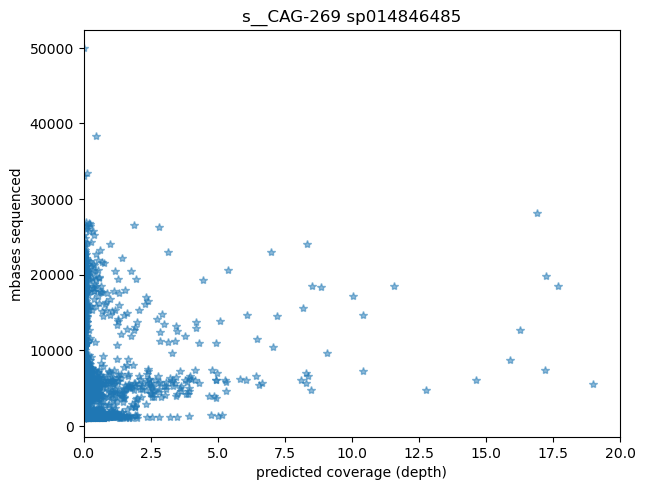

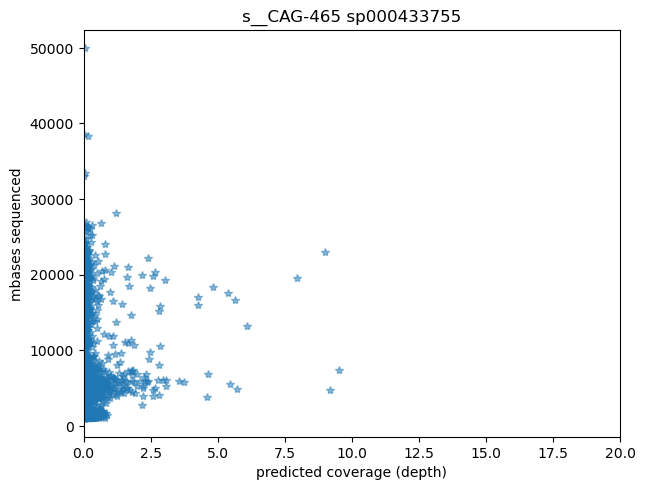

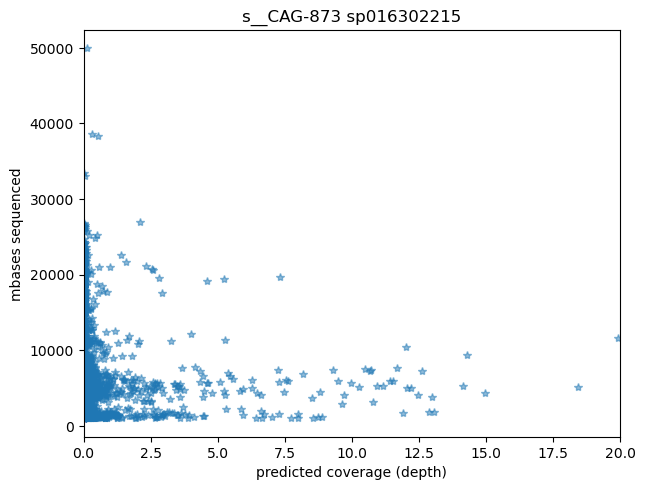

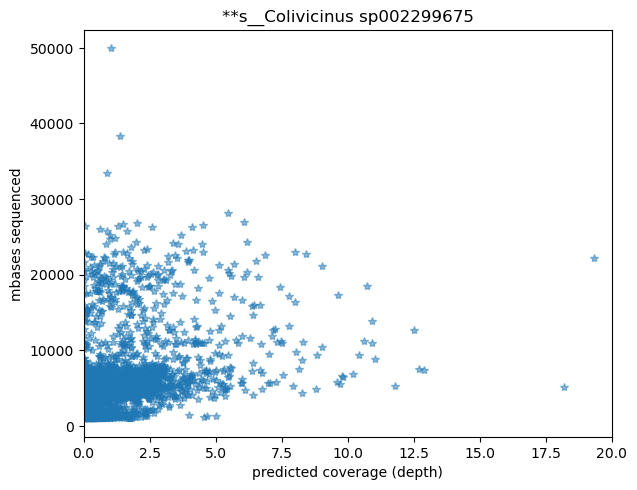

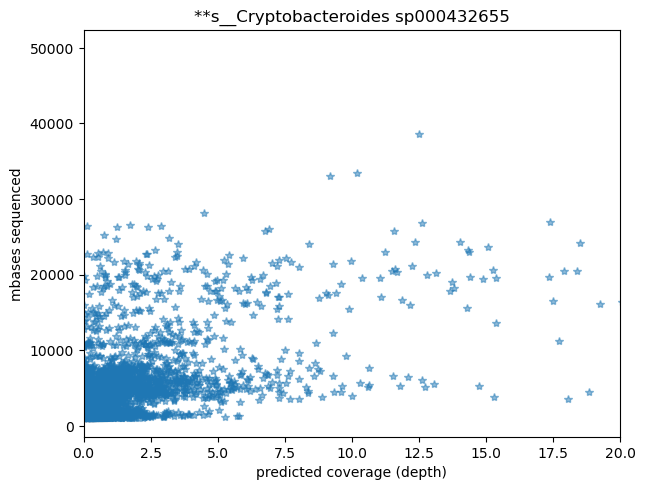

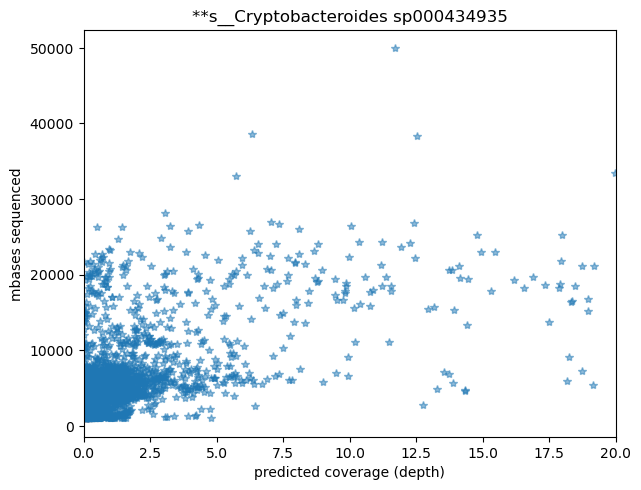

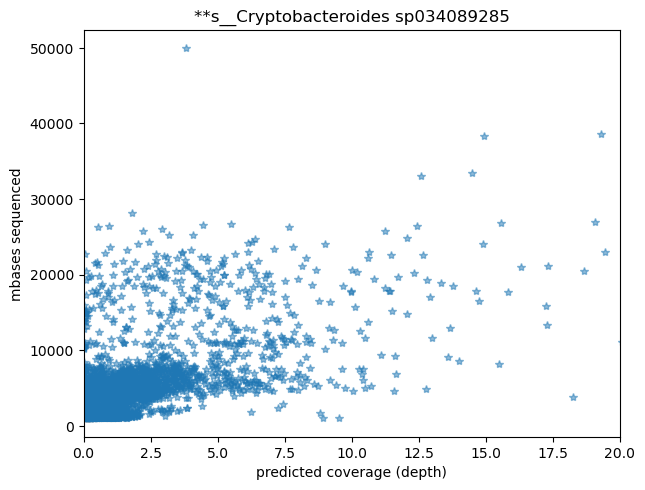

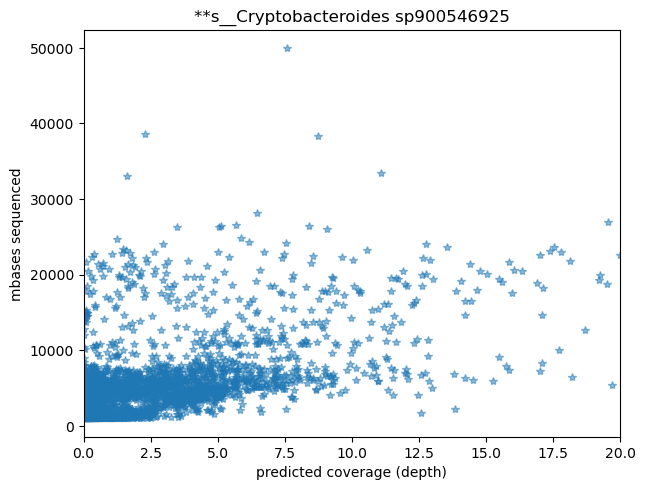

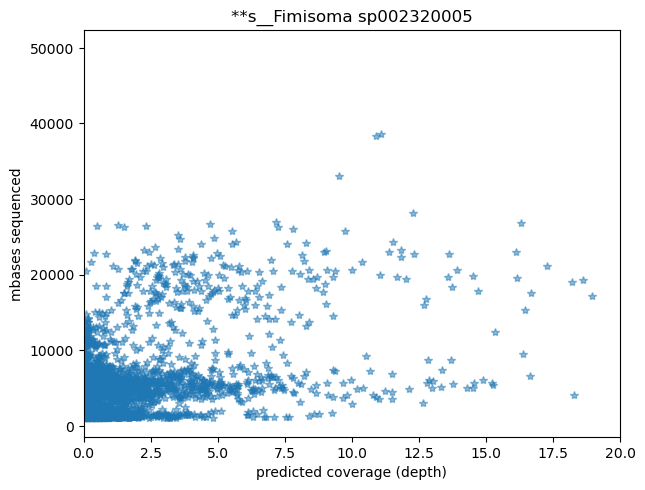

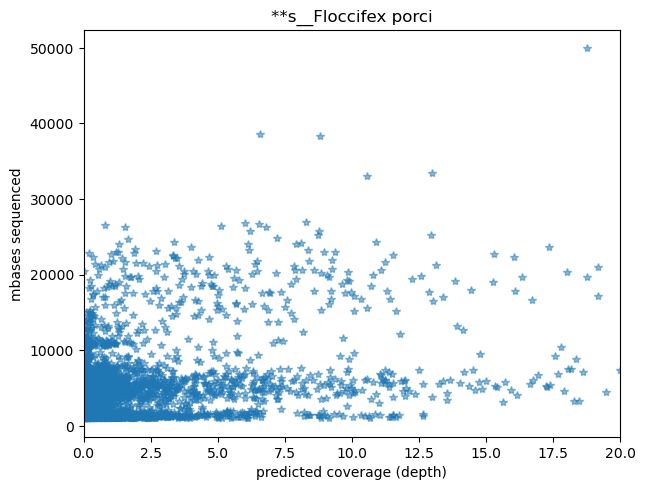

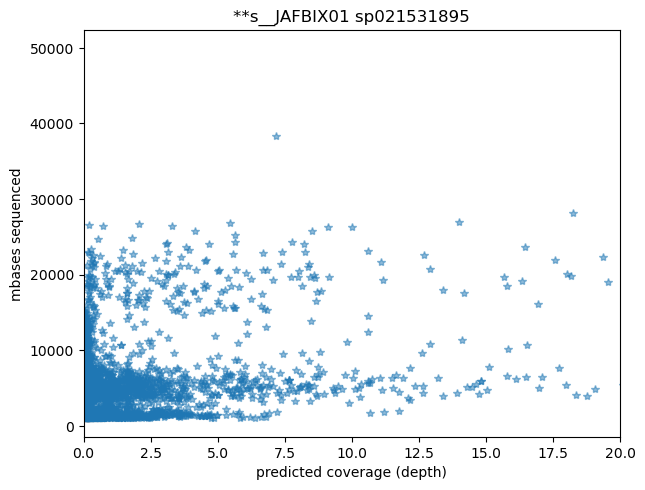

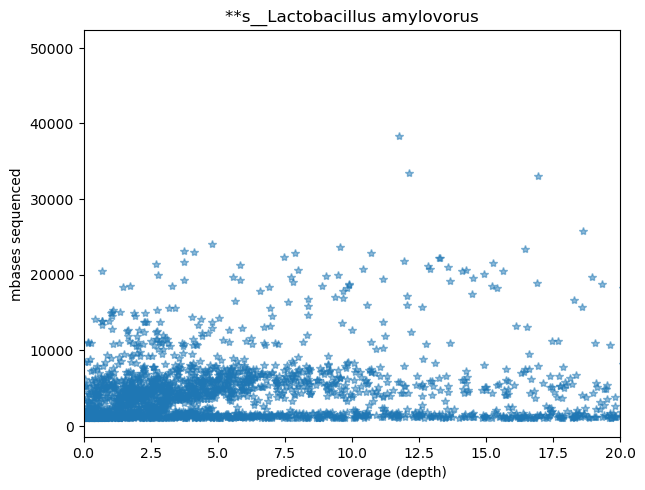

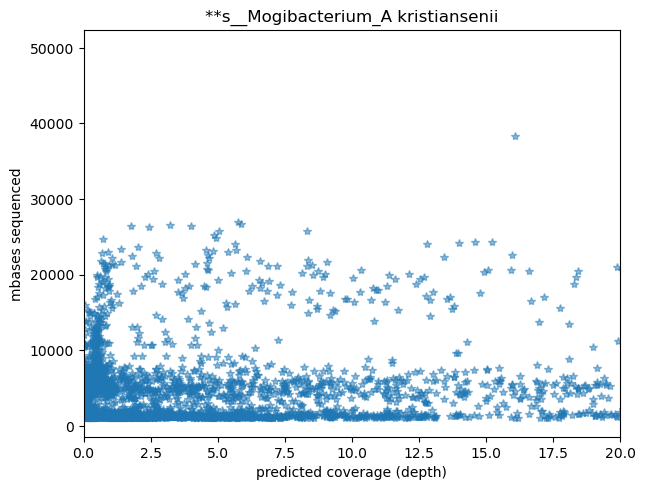

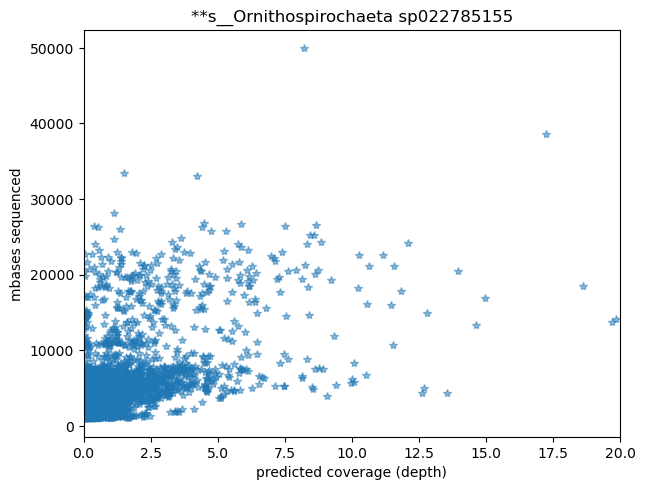

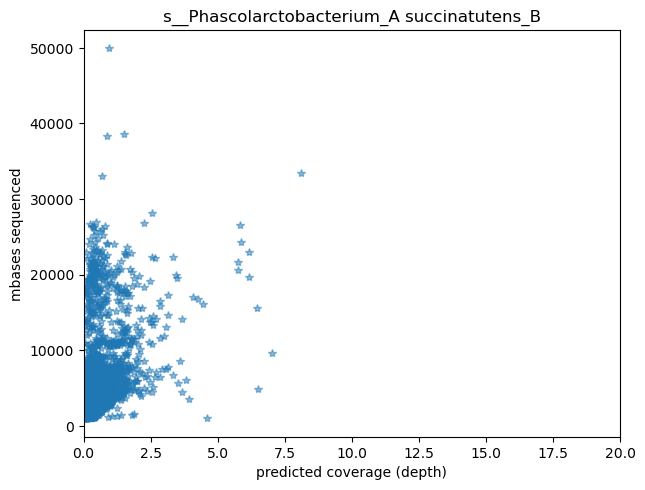

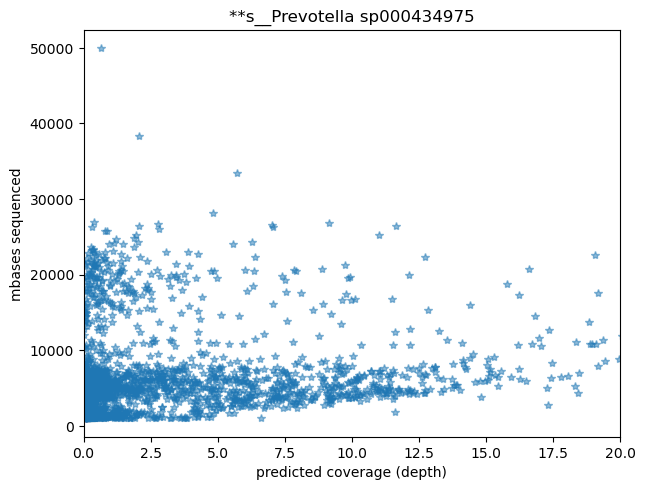

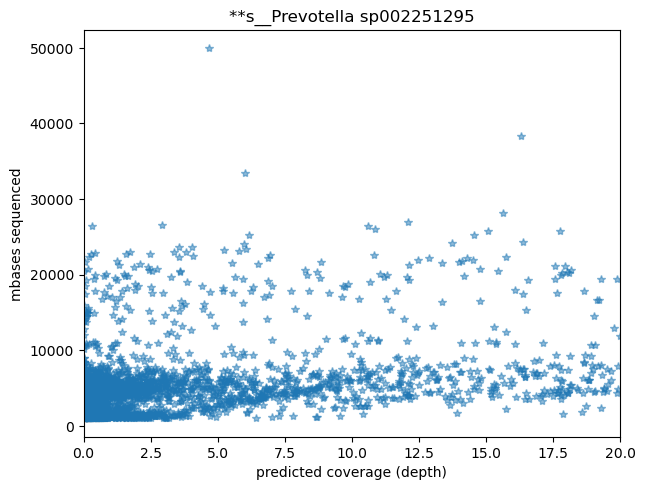

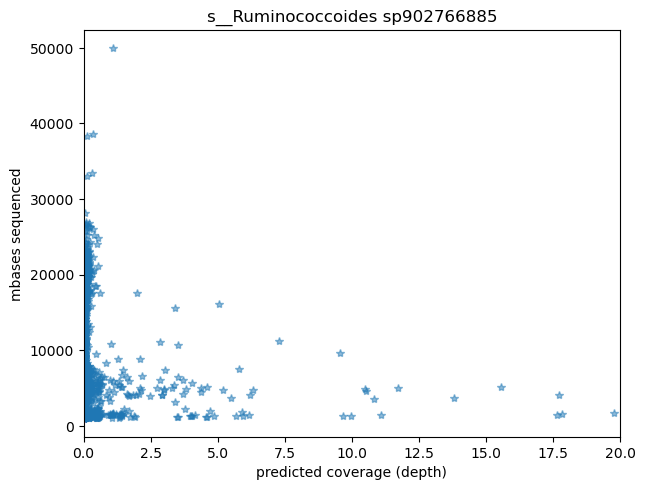

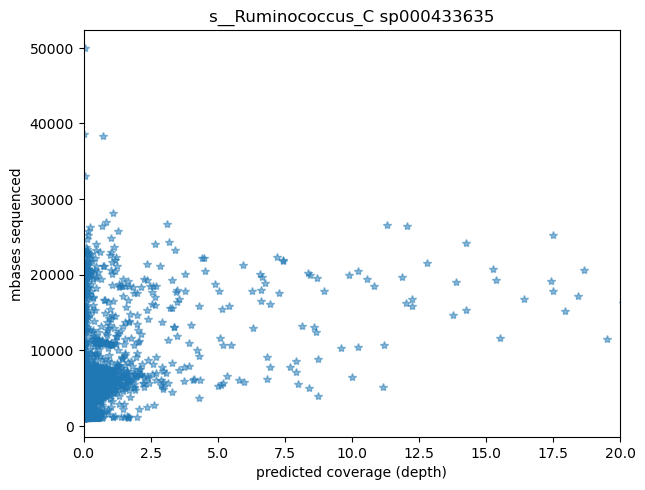

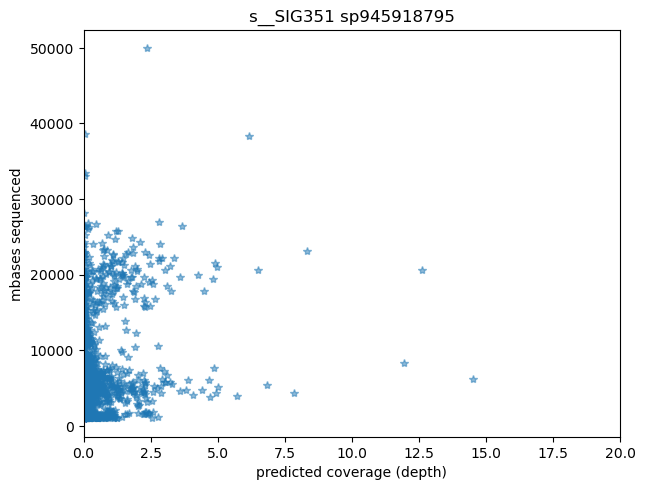

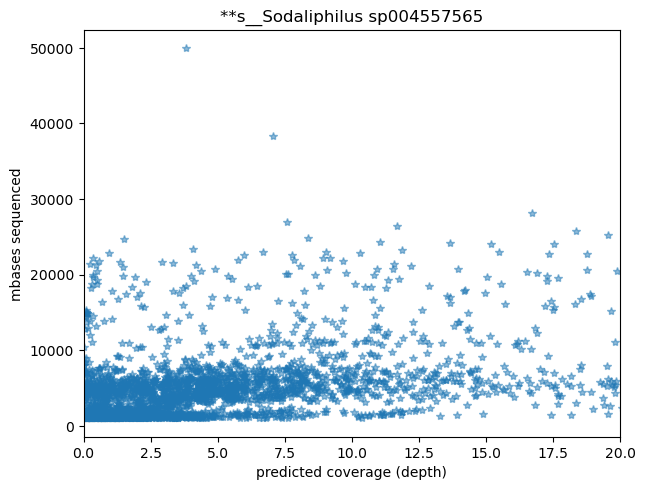

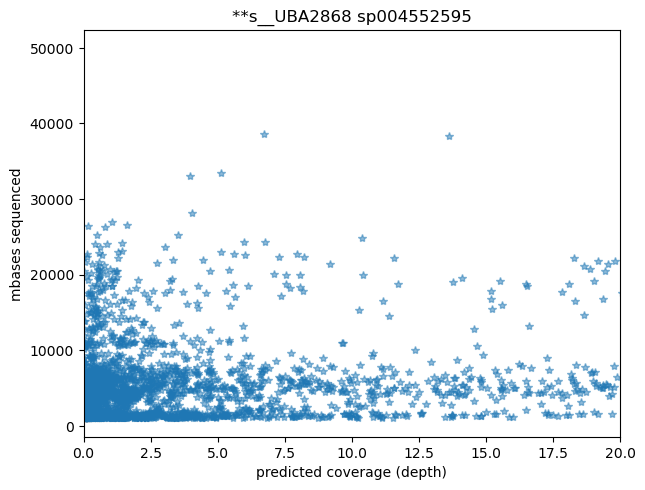

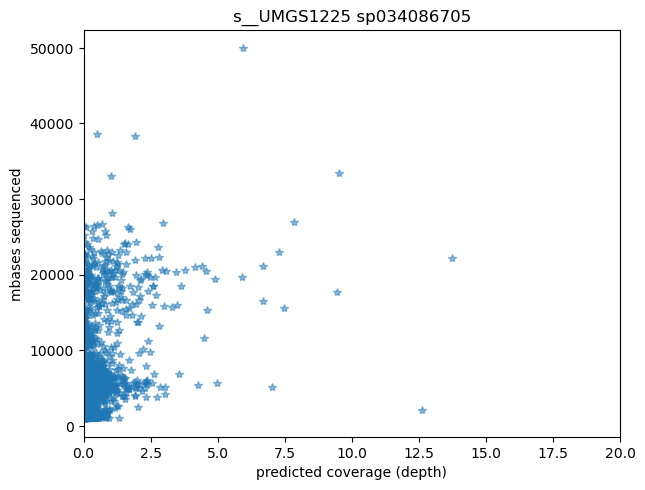

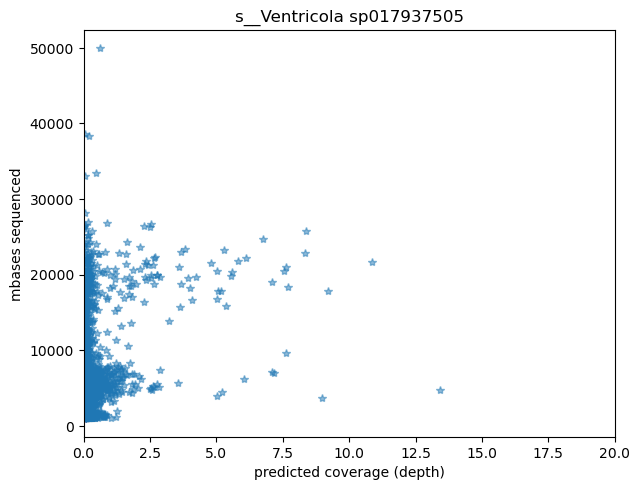

In [19]:
for name in sorted(NAMES):
    species_df = join_df.filter(pl.col("species") == name)
    foo_df = species_df.join(metadata_df, left_on='metag', right_on='acc', how='inner')
    plt.plot(foo_df['depth'], foo_df['mbases'], '*', alpha=0.5)
    plt.xlabel('predicted coverage (depth)')
    plt.ylabel('mbases sequenced')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlim(0, 20)
    plt.show()